# 📊 Bank Customer Churn Analysis 
### Author: Humendra Pun
### Date: 15/08/2025

## Phase 1: Data Understanding & Preparation 📁

---
### 🔍 1.1 Initial Data Exploration
- Load the dataset and check dimensions (rows × columns)
- Display first/last rows to understand structure
- Check data types of each column
- Understand what each column represents

In [1]:
# Import Required Libraries

# Data manipulation and analysis
import pandas as pd
import numpy as np

# Utilities
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime
import os
import sys

# Set display options for better visibility
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)  # Increase width
pd.set_option('display.float_format', '{:.2f}'.format)

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Set style for visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10


print("✅ Environment setup complete!")
print(f"📅 Analysis Date: {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print(f"🐍 Python Version: {sys.version.split()[0]}")
print(f"📊 Pandas Version: {pd.__version__}")
print(f"🔢 NumPy Version: {np.__version__}")
print(f"🎨 Seaborn Version: {sns.__version__}")

✅ Environment setup complete!
📅 Analysis Date: 2025-08-25 22:58
🐍 Python Version: 3.13.5
📊 Pandas Version: 2.2.3
🔢 NumPy Version: 2.1.3
🎨 Seaborn Version: 0.13.2


In [2]:
# Load the dataset
df = pd.read_csv('Churn_Modelling.csv')

print("✅ Data loaded successfully!")
print(f"📏 Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"💾 Memory Usage: {df.memory_usage().sum() / 1024**2:.2f} MB")

✅ Data loaded successfully!
📏 Dataset Shape: 10,002 rows × 14 columns
💾 Memory Usage: 1.07 MB


In [3]:
# Display first 5 rows
print("🔍 First 5 rows of the dataset:")
df.head()

🔍 First 5 rows of the dataset:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42.00,2,0.00,1,1.00,1.00,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41.00,1,83807.86,1,0.00,1.00,112542.58,0
2,3,15619304,Onio,502,France,Female,42.00,8,159660.80,3,1.00,0.00,113931.57,1
3,4,15701354,Boni,699,France,Female,39.00,1,0.00,2,0.00,0.00,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43.00,2,125510.82,1,NaN,1.00,79084.10,0


In [4]:
# Display last 5 rows
print("🔍 Last 5 rows of the dataset:")
df.tail()

🔍 Last 5 rows of the dataset:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
9997,9998,15584532,Liu,709,France,Female,36.00,7,0.00,1,0.00,1.00,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42.00,3,75075.31,2,1.00,0.00,92888.52,1
9999,9999,15682355,Sabbatini,772,Germany,Male,42.00,3,75075.31,2,1.00,0.00,92888.52,1
10000,10000,15628319,Walker,792,France,Female,28.00,4,130142.79,1,1.00,0.00,38190.78,0
10001,10000,15628319,Walker,792,France,Female,28.00,4,130142.79,1,1.00,0.00,38190.78,0


In [5]:
print("\n" + "="*50)
print("📁 INITIAL DATA EXPLORATION")
print("="*50)

# Basic information about the dataset
print("\n📊 Dataset Dimensions:")
print(f"   • Number of Rows (Customers): {df.shape[0]:,}")
print(f"   • Number of Columns (Features): {df.shape[1]}")

print("\n📋 Dataset Information:")
print("="*50)
df.info()


📁 INITIAL DATA EXPLORATION

📊 Dataset Dimensions:
   • Number of Rows (Customers): 10,002
   • Number of Columns (Features): 14

📋 Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10002 entries, 0 to 10001
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10002 non-null  int64  
 1   CustomerId       10002 non-null  int64  
 2   Surname          10002 non-null  object 
 3   CreditScore      10002 non-null  int64  
 4   Geography        10001 non-null  object 
 5   Gender           10002 non-null  object 
 6   Age              10001 non-null  float64
 7   Tenure           10002 non-null  int64  
 8   Balance          10002 non-null  float64
 9   NumOfProducts    10002 non-null  int64  
 10  HasCrCard        10001 non-null  float64
 11  IsActiveMember   10001 non-null  float64
 12  EstimatedSalary  10002 non-null  float64
 13  Exited           10002 non-null  int64  
dt

In [6]:
print("\n📊 Statistical Summary (Numerical Features):")
print("-" * 50)
print(df.describe())

print("\n📊 Statistical Summary (Categorical Features):")
print("-" * 50)
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(df[col].value_counts().head())
    print(f"Unique values: {df[col].nunique()}\n")


📊 Statistical Summary (Numerical Features):
--------------------------------------------------
       RowNumber  CustomerId  CreditScore      Age   Tenure   Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary   Exited
count   10002.00    10002.00     10002.00 10001.00 10002.00  10002.00       10002.00   10001.00        10001.00         10002.00 10002.00
mean     5001.50 15690933.45       650.56    38.92     5.01  76491.11           1.53       0.71            0.51        100083.33     0.20
std      2887.47    71931.77        96.66    10.49     2.89  62393.47           0.58       0.46            0.50         57508.12     0.40
min         1.00 15565701.00       350.00    18.00     0.00      0.00           1.00       0.00            0.00            11.58     0.00
25%      2501.25 15628524.75       584.00    32.00     3.00      0.00           1.00       0.00            0.00         50983.75     0.00
50%      5001.50 15690732.00       652.00    37.00     5.00  97198.54       

In [7]:
# Analyze the target variable
print("🎯 Target Variable (Exited) Analysis:")
print("="*50)

target_distribution = df['Exited'].value_counts()
target_percentage = df['Exited'].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    'Status': ['Retained (0)', 'Churned (1)'],
    'Count': target_distribution.values,
    'Percentage': target_percentage.values.round(2)
})

print(target_summary)



🎯 Target Variable (Exited) Analysis:
         Status  Count  Percentage
0  Retained (0)   7964       79.62
1   Churned (1)   2038       20.38


---
### 📋 1.2 Data Quality Assessment
- Check for missing values and their patterns
- Identify duplicates (if any)
- Look for data inconsistencies
- Validate data ranges (e.g., Age, CreditScore boundaries)

In [8]:
# Check for missing values
print("\n🔍 Missing Values Analysis:")
print("-" * 40)
missing_data = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_data = missing_data[missing_data['Missing_Count'] > 0]

if len(missing_data) > 0:
    print("\n⚠️  Columns with Missing Values:")
    for idx, row in missing_data.iterrows():
        print(f"   • {row['Column']:<20} : {row['Missing_Count']:>5} missing ({row['Missing_Percentage']:>5.2f}%)")
else:
    print("✅ No missing values found in the dataset!")


🔍 Missing Values Analysis:
----------------------------------------

⚠️  Columns with Missing Values:
   • Geography            :     1 missing ( 0.01%)
   • Age                  :     1 missing ( 0.01%)
   • HasCrCard            :     1 missing ( 0.01%)
   • IsActiveMember       :     1 missing ( 0.01%)


In [9]:
# Check for duplicates
print("\n🔍 Duplicate Records Analysis:")
print("-" * 40)

# Check for complete duplicates
complete_duplicates = df.duplicated().sum()
print(f"   • Complete duplicate rows: {complete_duplicates}")

# Check for duplicate customer IDs
duplicate_customers = df['CustomerId'].duplicated().sum()
print(f"   • Duplicate Customer IDs: {duplicate_customers}")

if duplicate_customers > 0:
    print("\n   📌 Duplicate Customer ID Details:")
    dup_customer_ids = df[df['CustomerId'].duplicated(keep=False)]['CustomerId'].value_counts()
    print(f"      Total unique customers with duplicates: {len(dup_customer_ids)}")
    print("\n      Sample of duplicate Customer IDs:")
    print(dup_customer_ids.head(10))


🔍 Duplicate Records Analysis:
----------------------------------------
   • Complete duplicate rows: 2
   • Duplicate Customer IDs: 2

   📌 Duplicate Customer ID Details:
      Total unique customers with duplicates: 2

      Sample of duplicate Customer IDs:
CustomerId
15682355    2
15628319    2
Name: count, dtype: int64


In [10]:
# Data consistency checks
print("\n🔍 Data Consistency Checks:")
print("-" * 40)

# Age validation
is_close_to_int = np.isclose(df['Age'], df['Age'].round(), rtol=1e-05, atol=1e-08)
age_issues = []
if df['Age'].min() < 18:
    age_issues.append(f"Minimum age ({df['Age'].min():.1f}) is below 18")
if df['Age'].max() > 100:
    age_issues.append(f"Maximum age ({df['Age'].max():.1f}) seems unrealistic")
if is_close_to_int.all() == False:
    age_issues.append(f"Some values are not integers. Example: {df['Age'][~is_close_to_int].head(5).tolist()}")

print("\n📌 Age Validation:")
if age_issues:
    for issue in age_issues:
        print(f"   ⚠️  {issue}")
else:
    print(f"   ✅ Age range is reasonable: {df['Age'].min():.0f} - {df['Age'].max():.0f} years and there is no unnatural/float values.")


🔍 Data Consistency Checks:
----------------------------------------

📌 Age Validation:
   ⚠️  Some values are not integers. Example: [nan, 45.25, 32.34, 36.44]


In [11]:
# Credit Score validation (typically 300-850)
print("\n📌 Credit Score Validation:")
credit_score_range = (df['CreditScore'].min(), df['CreditScore'].max())
if credit_score_range[0] < 300 or credit_score_range[1] > 850:
    print(f"   ⚠️  Credit scores outside typical range: {credit_score_range[0]} - {credit_score_range[1]}")
else:
    print(f"   ✅ Credit score range is valid: {credit_score_range[0]} - {credit_score_range[1]}")


📌 Credit Score Validation:
   ✅ Credit score range is valid: 350 - 850


In [12]:
# Binary columns validation
print("\n📌 Binary Columns Validation:")
binary_cols = ['HasCrCard', 'IsActiveMember', 'Exited']
for col in binary_cols:
    unique_vals = df[col].dropna().unique()
    if set(unique_vals).issubset({0, 1}):
        print(f"   ✅ {col:<20} : Contains only 0 and 1")
    else:
        print(f"   ⚠️  {col:<20} : Contains unexpected values: {unique_vals}")


📌 Binary Columns Validation:
   ✅ HasCrCard            : Contains only 0 and 1
   ✅ IsActiveMember       : Contains only 0 and 1
   ✅ Exited               : Contains only 0 and 1


In [13]:
# Tenure validation (0-10 years as per business logic)
print("\n📌 Tenure Validation:")
tenure_range = (df['Tenure'].min(), df['Tenure'].max())
print(f"   • Tenure range: {tenure_range[0]} - {tenure_range[1]} years")
if tenure_range[0] < 0:
    print(f"   ⚠️  Negative tenure values found")
elif tenure_range[1] > 10:
    print(f"   ⚠️  Tenure exceeds 10 years")
else:
    print(f"   ✅ Tenure range is valid")


📌 Tenure Validation:
   • Tenure range: 0 - 10 years
   ✅ Tenure range is valid


In [14]:
# NumOfProducts validation
print("\n📌 Number of Products Validation:")
products_range = df['NumOfProducts'].value_counts().sort_index()
print("   Product distribution:")
for prod, count in products_range.items():
    print(f"      {prod} product(s): {count:>5} customers ({count/len(df)*100:>5.2f}%)")


📌 Number of Products Validation:
   Product distribution:
      1 product(s):  5085 customers (50.84%)
      2 product(s):  4591 customers (45.90%)
      3 product(s):   266 customers ( 2.66%)
      4 product(s):    60 customers ( 0.60%)


In [15]:
# Balance validation
print("\n📌 Account Balance Validation:")
zero_balance = (df['Balance'] == 0).sum()
print(f"   • Customers with zero balance: {zero_balance:,} ({zero_balance/len(df)*100:.2f}%)")
print(f"   • Customers with positive balance: {(df['Balance'] > 0).sum():,} ({(df['Balance'] > 0).sum()/len(df)*100:.2f}%)")
negative_balance = (df['Balance'] < 0).sum()
if negative_balance > 0:
    print(f"   ⚠️  Customers with negative balance: {negative_balance}")


📌 Account Balance Validation:
   • Customers with zero balance: 3,617 (36.16%)
   • Customers with positive balance: 6,385 (63.84%)


In [16]:
# Salary validation
print("\n📌 Estimated Salary Validation:")
salary_range = (df['EstimatedSalary'].min(), df['EstimatedSalary'].max())
print(f"   • Salary range: ${salary_range[0]:,.2f} - ${salary_range[1]:,.2f}")
if salary_range[0] <= 0:
    print(f"   ⚠️  Zero or negative salaries found: {(df['EstimatedSalary'] <= 0).sum()} records")


📌 Estimated Salary Validation:
   • Salary range: $11.58 - $199,992.48


---
### 🧹 1.3 Data Cleaning
- Handle missing values (drop/impute)
- Remove unnecessary columns (RowNumber, CustomerId, Surname)
- Fix data type issues
- Handle outliers if needed

In [17]:
# Create a copy for cleaning
df_clean = df.copy()

print("\n📊 Initial Dataset Shape: ", df_clean.shape)

# Step 1: Handle duplicate records
print("\n1️⃣ Handling Duplicate Records:")
print("-" * 40)
print(f"   • Duplicate rows before cleaning: {df_clean.duplicated().sum()}")

# Remove complete duplicates
df_clean = df_clean.drop_duplicates()
print(f"   • Duplicate rows after cleaning: {df_clean.duplicated().sum()}")
print(f"   ✅ Removed {df.shape[0] - df_clean.shape[0]} duplicate rows")


📊 Initial Dataset Shape:  (10002, 14)

1️⃣ Handling Duplicate Records:
----------------------------------------
   • Duplicate rows before cleaning: 2
   • Duplicate rows after cleaning: 0
   ✅ Removed 2 duplicate rows


In [18]:
# Step 2: Handle missing values
print("\n2️⃣ Handling Missing Values:")
print("-" * 40)

# Check missing values before cleaning
missing_before = df_clean.isnull().sum()

# Fill missing values with loop
fill_strategy = {
    'Geography': ('mode', lambda x: x),
    'Age': ('median', lambda x: f"{x:.0f}"),
    'HasCrCard': ('mode', lambda x: int(x)),
    'IsActiveMember': ('mode', lambda x: int(x))
}

for col, (method, formatter) in fill_strategy.items():
    if df_clean[col].isnull().sum() > 0:
        fill_value = df_clean[col].mode()[0] if method == 'mode' else df_clean[col].median()
        df_clean[col].fillna(fill_value, inplace=True)
        print(f"   • {col}: Filled {missing_before[col]} missing values with {method} ({formatter(fill_value)})")

print("\n   ✅ All missing values have been handled")


2️⃣ Handling Missing Values:
----------------------------------------
   • Geography: Filled 1 missing values with mode (France)
   • Age: Filled 1 missing values with median (37)
   • HasCrCard: Filled 1 missing values with mode (1)
   • IsActiveMember: Filled 1 missing values with mode (1)

   ✅ All missing values have been handled


In [19]:
# Step 3: Remove unnecessary columns
print("\n3️⃣ Removing Unnecessary Columns:")
print("-" * 40)
columns_to_drop = ['RowNumber', 'CustomerId', 'Surname']
df_clean = df_clean.drop(columns=columns_to_drop)
print(f"   • Dropped columns: {', '.join(columns_to_drop)}")
print(f"   ✅ Remaining columns: {df_clean.shape[1]}")


3️⃣ Removing Unnecessary Columns:
----------------------------------------
   • Dropped columns: RowNumber, CustomerId, Surname
   ✅ Remaining columns: 11


In [20]:
# Step 4: Data type corrections
print("\n4️⃣ Data Type Corrections:")
print("-" * 40)

# Convert binary columns to integer
binary_cols = ['HasCrCard', 'IsActiveMember']
for col in binary_cols:
    df_clean[col] = df_clean[col].astype(int)
    print(f"   • {col}: Converted to integer type")

# Ensure Age is integer
df_clean['Age'] = df_clean['Age'].astype(int)
print(f"   • Age: Converted to integer type")
print("\n   ✅ Data types corrected")


4️⃣ Data Type Corrections:
----------------------------------------
   • HasCrCard: Converted to integer type
   • IsActiveMember: Converted to integer type
   • Age: Converted to integer type

   ✅ Data types corrected


In [21]:
# Step 5: Outlier Detection (for information only, not removing yet)
print("\n5️⃣ Outlier Detection (Information Only):")
print("-" * 40)

numerical_cols = ['CreditScore', 'Age', 'Balance', 'EstimatedSalary']

for col in numerical_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]
    outlier_count = len(outliers)
    outlier_pct = (outlier_count / len(df_clean)) * 100
    
    print(f"\n   📊 {col}:")
    print(f"      • IQR Range: [{Q1:.2f}, {Q3:.2f}]")
    print(f"      • Outlier bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"      • Outliers detected: {outlier_count} ({outlier_pct:.2f}%)")


5️⃣ Outlier Detection (Information Only):
----------------------------------------

   📊 CreditScore:
      • IQR Range: [584.00, 718.00]
      • Outlier bounds: [383.00, 919.00]
      • Outliers detected: 15 (0.15%)

   📊 Age:
      • IQR Range: [32.00, 44.00]
      • Outlier bounds: [14.00, 62.00]
      • Outliers detected: 359 (3.59%)

   📊 Balance:
      • IQR Range: [0.00, 127644.24]
      • Outlier bounds: [-191466.36, 319110.60]
      • Outliers detected: 0 (0.00%)

   📊 EstimatedSalary:
      • IQR Range: [51002.11, 149388.25]
      • Outlier bounds: [-96577.10, 296967.45]
      • Outliers detected: 0 (0.00%)


In [22]:
# Step 6: Final Checking and save dataset
print("\n" + "="*50)
print("📊 FINAL CLEANED DATASET SUMMARY")
print("="*50)

print(f"\n✅ Original Dataset Shape: {df.shape}")
print(f"✅ Cleaned Dataset Shape: {df_clean.shape}")
print(f"✅ Rows removed: {df.shape[0] - df_clean.shape[0]}")
print(f"✅ Columns removed: {df.shape[1] - df_clean.shape[1]}")

print("\n🔍 Final Missing Values Check:")
final_missing = df_clean.isnull().sum().sum()
if final_missing == 0:
    print("   ✅ No missing values in the cleaned dataset!")
else:
    print(f"   ⚠️ Still {final_missing} missing values remaining")

print("\n📋 Final Dataset Info:")
print("-" * 40)
print(df_clean.info())

# Save the cleaned dataset
df_clean.to_csv('bank_churn_cleaned.csv', index=False)
print("\n💾 Cleaned dataset saved as 'bank_churn_cleaned.csv'")


📊 FINAL CLEANED DATASET SUMMARY

✅ Original Dataset Shape: (10002, 14)
✅ Cleaned Dataset Shape: (10000, 11)
✅ Rows removed: 2
✅ Columns removed: 3

🔍 Final Missing Values Check:
   ✅ No missing values in the cleaned dataset!

📋 Final Dataset Info:
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 10000
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: 

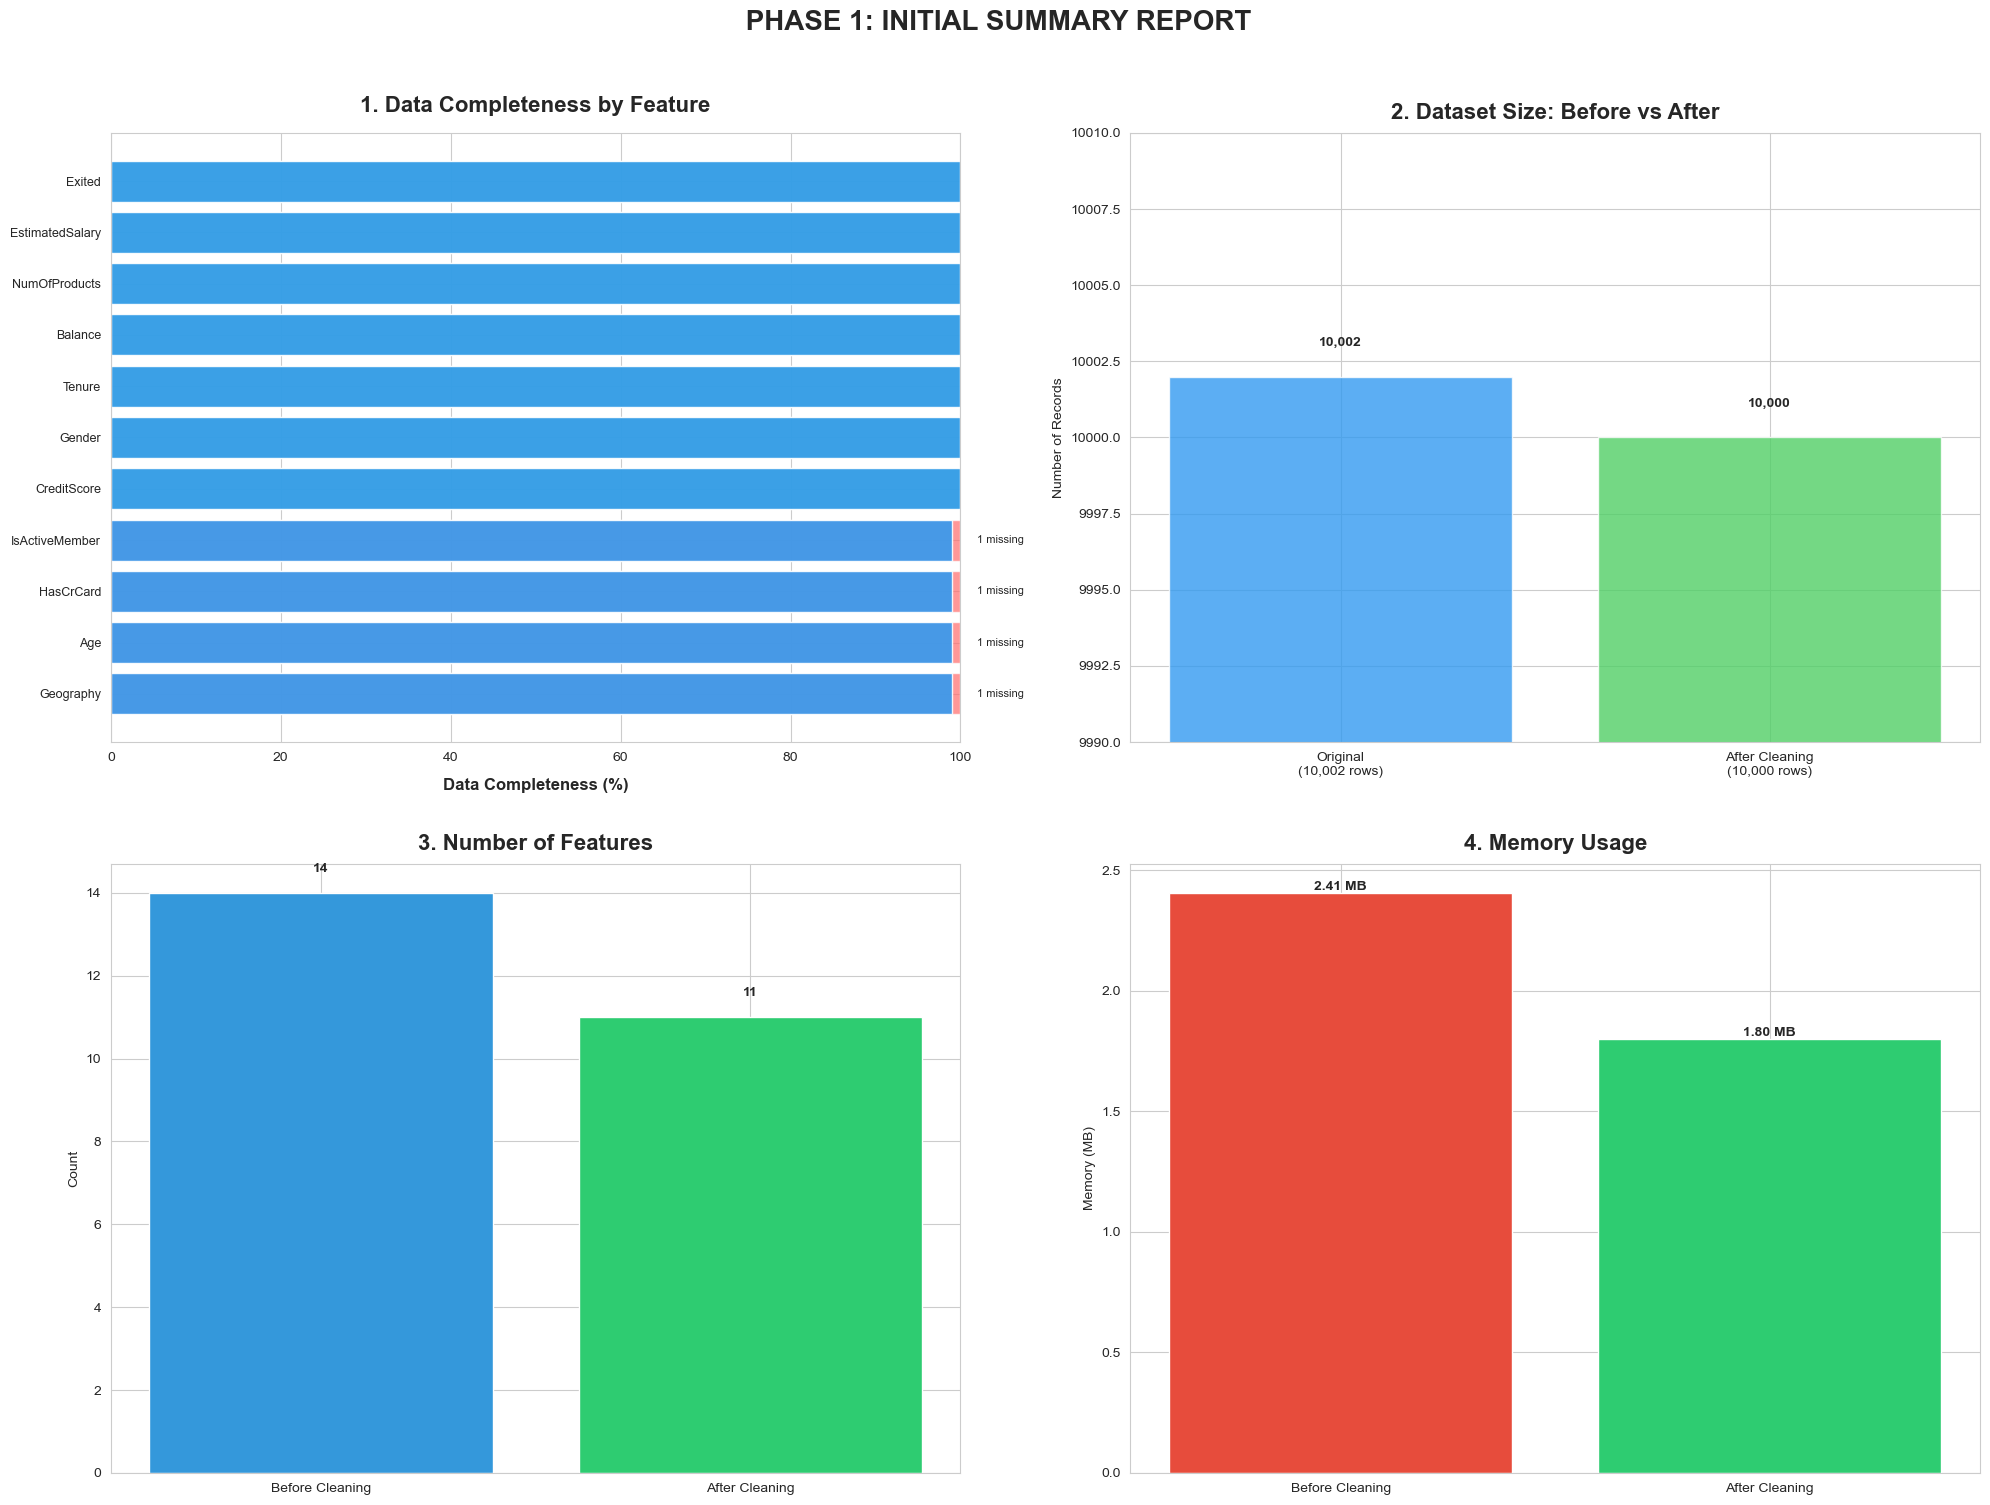

In [23]:
# Create a comprehensive visualization report
fig = plt.figure(figsize=(20, 15))
fig.suptitle(' PHASE 1: INITIAL SUMMARY REPORT', fontsize=20, fontweight='bold', x=.5, y=1)

# 1. Data Completeness Overview
ax1 = plt.subplot(2, 2, 1)
missing_original = pd.Series([1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0], 
                             index=['Geography', 'Age', 'HasCrCard', 'IsActiveMember',
                                   'CreditScore', 'Gender', 'Tenure', 'Balance', 
                                   'NumOfProducts', 'EstimatedSalary', 'Exited'])
colors = ['#ff6b6b' if x > 0 else '#51cf66' for x in missing_original]
bars = ax1.barh(range(len(missing_original)), [100]*len(missing_original), color=colors, alpha=0.7)
ax1.barh(range(len(missing_original)), [100-x for x in missing_original], color='#339af0', alpha=0.9)
ax1.set_yticks(range(len(missing_original)))
ax1.set_yticklabels(missing_original.index, fontsize=9)
ax1.set_xlabel('Data Completeness (%)', fontsize=12, fontweight='bold', labelpad=10)
ax1.set_title('1. Data Completeness by Feature', fontweight='bold', fontsize=16, pad=15)
ax1.set_xlim(0, 100)
for i, v in enumerate(missing_original):
    if v > 0:
        ax1.text(102, i, f'{v} missing', fontsize=8, va='center')

# 2. Dataset Size Comparison
ax2 = plt.subplot(2, 2, 2)
sizes = ['Original\n(10,002 rows)', 'After Cleaning\n(10,000 rows)']
values = [10002, 10000]
colors_size = ['#339af0', '#51cf66']
bars = ax2.bar(sizes, values, color=colors_size, alpha=0.8)
ax2.set_ylabel('Number of Records')
ax2.set_title('2. Dataset Size: Before vs After', fontweight='bold', fontsize=16, pad=10)
ax2.set_ylim(9990, 10010)
for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:,}', 
             ha='center', fontweight='bold')

# 3. Features Comparison
ax4 = plt.subplot(2, 2, 3)
comparison_data = pd.DataFrame({
    'Stage': ['Before Cleaning', 'After Cleaning'],
    'Features': [df.shape[1], df_clean.shape[1]]
})
bars = ax4.bar(comparison_data['Stage'], comparison_data['Features'], 
               color=['#3498db', '#2ecc71'])
ax4.set_title('3. Number of Features', fontweight='bold', fontsize=16, pad=10)
ax4.set_ylabel('Count')
for i, v in enumerate(comparison_data['Features']):
    ax4.text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# 4. Memory Usage Comparison
ax5 = plt.subplot(2, 2, 4)
memory_data = [
    df.memory_usage(deep=True).sum() / 1024**2,
    df_clean.memory_usage(deep=True).sum() / 1024**2
]
bars = ax5.bar(['Before Cleaning', 'After Cleaning'], memory_data, 
               color=['#e74c3c', '#2ecc71'])
ax5.set_title('4. Memory Usage', fontweight='bold', fontsize=16, pad=10)
ax5.set_ylabel('Memory (MB)')
for i, v in enumerate(memory_data):
    ax5.text(i, v + 0.01, f'{v:.2f} MB', ha='center', fontweight='bold')


fig.tight_layout(rect=[0, 0, 1, .98])   # leaves top 2% for the suptitle
fig.subplots_adjust(hspace=0.2, wspace=0.2)  # add extra vertical/horizontal padding
plt.show()

In [24]:
print("\n" + "="*80)
print(" " * 25 + "📊 DATA PREPARATION COMPLETE!")
print("="*80)
print("\n✅ Phase 1 Summary:")
print("-" * 40)
print(f"• Total customers analyzed: {len(df_clean):,}")
print(f"• Features available for analysis: {len(df_clean.columns)}")
print(f"• Target variable (Exited): {df_clean['Exited'].sum():,} churned ({df_clean['Exited'].mean()*100:.1f}%)")
print(f"• Data quality: 100% complete (no missing values)")
print(f"• Duplicates removed: 2 records")
print(f"• Dataset saved: 'bank_churn_cleaned.csv'")
print("\n📌 Key Observations from Initial Analysis:")
print("-" * 40)
print(f"• Customer age range: {df_clean['Age'].min()}-{df_clean['Age'].max()} years")
print(f"• Credit score range: {df_clean['CreditScore'].min()}-{df_clean['CreditScore'].max()}")
print(f"• Geographic distribution: France ({(df_clean['Geography']=='France').sum():,}), Germany ({(df_clean['Geography']=='Germany').sum():,}), Spain ({(df_clean['Geography']=='Spain').sum():,})")
print(f"• Gender split: Male ({(df_clean['Gender']=='Male').sum():,}), Female ({(df_clean['Gender']=='Female').sum():,})")
print(f"• Zero balance accounts: {(df_clean['Balance']==0).sum():,} ({(df_clean['Balance']==0).mean()*100:.1f}%)")


                         📊 DATA PREPARATION COMPLETE!

✅ Phase 1 Summary:
----------------------------------------
• Total customers analyzed: 10,000
• Features available for analysis: 11
• Target variable (Exited): 2,037 churned (20.4%)
• Data quality: 100% complete (no missing values)
• Duplicates removed: 2 records
• Dataset saved: 'bank_churn_cleaned.csv'

📌 Key Observations from Initial Analysis:
----------------------------------------
• Customer age range: 18-92 years
• Credit score range: 350-850
• Geographic distribution: France (5,014), Germany (2,509), Spain (2,477)
• Gender split: Male (5,457), Female (4,543)
• Zero balance accounts: 3,617 (36.2%)


---
# Phase 2: Exploratory Data Analysis (EDA) 📈

### 📊 2.1 Univariate Analysis
- Numerical Variables:
    Distribution plots for Age, Balance, CreditScore, EstimatedSalary
    -- Summary statistics (mean, median, std, quartiles)
- - Box plots to identify outliers
Categorical Variables:
Frequency counts for Geography, Gender, NumOfProducts
Bar charts for HasCrCard, IsActiveMember, Exited


In [25]:
# Load the cleaned dataset
df_clean = pd.read_csv('bank_churn_cleaned.csv')

print("=" * 80)
print(" " * 20 + "BANK CUSTOMER CHURN ANALYSIS")
print(" " * 15 + "Phase 2: Exploratory Data Analysis (EDA)")
print("=" * 80)
print("Dataset: Bank Customer Churn Data (Cleaned)")
print(f"Total Records: {len(df_clean):,}")
print("-" * 80)

                    BANK CUSTOMER CHURN ANALYSIS
               Phase 2: Exploratory Data Analysis (EDA)
Dataset: Bank Customer Churn Data (Cleaned)
Total Records: 10,000
--------------------------------------------------------------------------------


In [26]:
print("\n" + "="*50)
print("📊 2.1 UNIVARIATE ANALYSIS")
print("="*50)

print("\n" + "-"*40)
print("📈 NUMERICAL VARIABLES ANALYSIS")
print("-"*40)

# Numerical columns
numerical_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']

print("\n📊 Statistical Summary of Numerical Features:")
print("-" * 40)

for col in numerical_cols:
    print(f"\n📌 {col}:")
    print(f"   • Mean     : {df_clean[col].mean():,.2f}")
    print(f"   • Median   : {df_clean[col].median():,.2f}")
    print(f"   • Mode     : {df_clean[col].mode()[0]:,.2f}")
    print(f"   • Std Dev  : {df_clean[col].std():,.2f}")
    print(f"   • Variance : {df_clean[col].var():,.2f}")
    print(f"   • Skewness : {df_clean[col].skew():.3f}")
    print(f"   • Kurtosis : {df_clean[col].kurtosis():.3f}")
    print(f"   • Range    : {df_clean[col].max() - df_clean[col].min():,.2f}")
    print(f"   • IQR      : {df_clean[col].quantile(0.75) - df_clean[col].quantile(0.25):,.2f}")
    print(f"   • CV       : {(df_clean[col].std() / df_clean[col].mean()) * 100:.2f}%")


📊 2.1 UNIVARIATE ANALYSIS

----------------------------------------
📈 NUMERICAL VARIABLES ANALYSIS
----------------------------------------

📊 Statistical Summary of Numerical Features:
----------------------------------------

📌 CreditScore:
   • Mean     : 650.53
   • Median   : 652.00
   • Mode     : 850.00
   • Std Dev  : 96.65
   • Variance : 9,341.86
   • Skewness : -0.072
   • Kurtosis : -0.426
   • Range    : 500.00
   • IQR      : 134.00
   • CV       : 14.86%

📌 Age:
   • Mean     : 38.92
   • Median   : 37.00
   • Mode     : 37.00
   • Std Dev  : 10.49
   • Variance : 109.98
   • Skewness : 1.011
   • Kurtosis : 1.396
   • Range    : 74.00
   • IQR      : 12.00
   • CV       : 26.94%

📌 Tenure:
   • Mean     : 5.01
   • Median   : 5.00
   • Mode     : 2.00
   • Std Dev  : 2.89
   • Variance : 8.36
   • Skewness : 0.011
   • Kurtosis : -1.165
   • Range    : 10.00
   • IQR      : 4.00
   • CV       : 57.70%

📌 Balance:
   • Mean     : 76,485.89
   • Median   : 97,198.54
   •

In [27]:
print("\n" + "-"*40)
print("📊 CATEGORICAL VARIABLES ANALYSIS")
print("-"*40)

# Categorical columns
categorical_cols = ['Geography', 'Gender', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'Exited']

print("\n📊 Frequency Distribution of Categorical Features:")
print("-" * 40)

for col in categorical_cols:
    print(f"\n📌 {col}:")
    value_counts = df_clean[col].value_counts()
    for value, count in value_counts.items():
        percentage = (count / len(df_clean)) * 100
        print(f"   • {value:<15} : {count:>5,} ({percentage:>6.2f}%)")
    
    # Add mode and unique count
    print(f"   ─────────────────────────")
    print(f"   Mode: {df_clean[col].mode()[0]}")
    print(f"   Unique Values: {df_clean[col].nunique()}")


----------------------------------------
📊 CATEGORICAL VARIABLES ANALYSIS
----------------------------------------

📊 Frequency Distribution of Categorical Features:
----------------------------------------

📌 Geography:
   • France          : 5,014 ( 50.14%)
   • Germany         : 2,509 ( 25.09%)
   • Spain           : 2,477 ( 24.77%)
   ─────────────────────────
   Mode: France
   Unique Values: 3

📌 Gender:
   • Male            : 5,457 ( 54.57%)
   • Female          : 4,543 ( 45.43%)
   ─────────────────────────
   Mode: Male
   Unique Values: 2

📌 NumOfProducts:
   • 1               : 5,084 ( 50.84%)
   • 2               : 4,590 ( 45.90%)
   • 3               :   266 (  2.66%)
   • 4               :    60 (  0.60%)
   ─────────────────────────
   Mode: 1
   Unique Values: 4

📌 HasCrCard:
   • 1               : 7,055 ( 70.55%)
   • 0               : 2,945 ( 29.45%)
   ─────────────────────────
   Mode: 1
   Unique Values: 2

📌 IsActiveMember:
   • 1               : 5,151 ( 51.51%)


In [28]:
print("\n" + "="*50)
print("📊 DISTRIBUTION INSIGHTS")
print("="*50)

print("\n📌 Key Distribution Findings:")
print("-" * 40)

# Age insights
age_groups = pd.cut(df_clean['Age'], bins=[0, 30, 40, 50, 60, 100], 
                    labels=['18-30', '31-40', '41-50', '51-60', '60+'])
print("\n1. Age Distribution:")
for group in age_groups.value_counts().sort_index().items():
    print(f"   • {group[0]}: {group[1]:,} customers ({group[1]/len(df_clean)*100:.1f}%)")

# Balance insights
print("\n2. Balance Distribution:")
print(f"   • Zero Balance: {(df_clean['Balance'] == 0).sum():,} ({(df_clean['Balance'] == 0).mean()*100:.1f}%)")
print(f"   • Below 50k: {(df_clean['Balance'].between(0.01, 50000)).sum():,} ({(df_clean['Balance'].between(0.01, 50000)).mean()*100:.1f}%)")
print(f"   • 50k-100k: {(df_clean['Balance'].between(50000, 100000)).sum():,} ({(df_clean['Balance'].between(50000, 100000)).mean()*100:.1f}%)")
print(f"   • 100k-150k: {(df_clean['Balance'].between(100000, 150000)).sum():,} ({(df_clean['Balance'].between(100000, 150000)).mean()*100:.1f}%)")
print(f"   • Above 150k: {(df_clean['Balance'] > 150000).sum():,} ({(df_clean['Balance'] > 150000).mean()*100:.1f}%)")

# Credit Score insights
print("\n3. Credit Score Categories:")
credit_categories = pd.cut(df_clean['CreditScore'], 
                          bins=[0, 580, 670, 740, 800, 850],
                          labels=['Poor (300-579)', 'Fair (580-669)', 'Good (670-739)', 'Very Good (740-799)', 'Excellent (800-850)'])
for category in credit_categories.value_counts().sort_index().items():
    print(f"   • {category[0]}: {category[1]:,} customers ({category[1]/len(df_clean)*100:.1f}%)")

# Tenure insights
print("\n4. Customer Tenure:")
print(f"   • New (0-2 years): {(df_clean['Tenure'] <= 2).sum():,} ({(df_clean['Tenure'] <= 2).mean()*100:.1f}%)")
print(f"   • Medium (3-6 years): {(df_clean['Tenure'].between(3, 6)).sum():,} ({(df_clean['Tenure'].between(3, 6)).mean()*100:.1f}%)")
print(f"   • Long (7-10 years): {(df_clean['Tenure'] >= 7).sum():,} ({(df_clean['Tenure'] >= 7).mean()*100:.1f}%)")

# Salary insights
print("\n5. Salary Brackets:")
salary_brackets = pd.cut(df_clean['EstimatedSalary'], 
                         bins=[0, 50000, 100000, 150000, 200000],
                         labels=['<50k', '50k-100k', '100k-150k', '150k+'])
for bracket in salary_brackets.value_counts().sort_index().items():
    print(f"   • {bracket[0]}: {bracket[1]:,} customers ({bracket[1]/len(df_clean)*100:.1f}%)")


📊 DISTRIBUTION INSIGHTS

📌 Key Distribution Findings:
----------------------------------------

1. Age Distribution:
   • 18-30: 1,967 customers (19.7%)
   • 31-40: 4,452 customers (44.5%)
   • 41-50: 2,320 customers (23.2%)
   • 51-60: 797 customers (8.0%)
   • 60+: 464 customers (4.6%)

2. Balance Distribution:
   • Zero Balance: 3,617 (36.2%)
   • Below 50k: 75 (0.8%)
   • 50k-100k: 1,509 (15.1%)
   • 100k-150k: 3,830 (38.3%)
   • Above 150k: 969 (9.7%)

3. Credit Score Categories:
   • Poor (300-579): 2,393 customers (23.9%)
   • Fair (580-669): 3,350 customers (33.5%)
   • Good (670-739): 2,397 customers (24.0%)
   • Very Good (740-799): 1,215 customers (12.2%)
   • Excellent (800-850): 645 customers (6.5%)

4. Customer Tenure:
   • New (0-2 years): 2,496 (25.0%)
   • Medium (3-6 years): 3,977 (39.8%)
   • Long (7-10 years): 3,527 (35.3%)

5. Salary Brackets:
   • <50k: 2,453 customers (24.5%)
   • 50k-100k: 2,537 customers (25.4%)
   • 100k-150k: 2,555 customers (25.6%)
   • 150

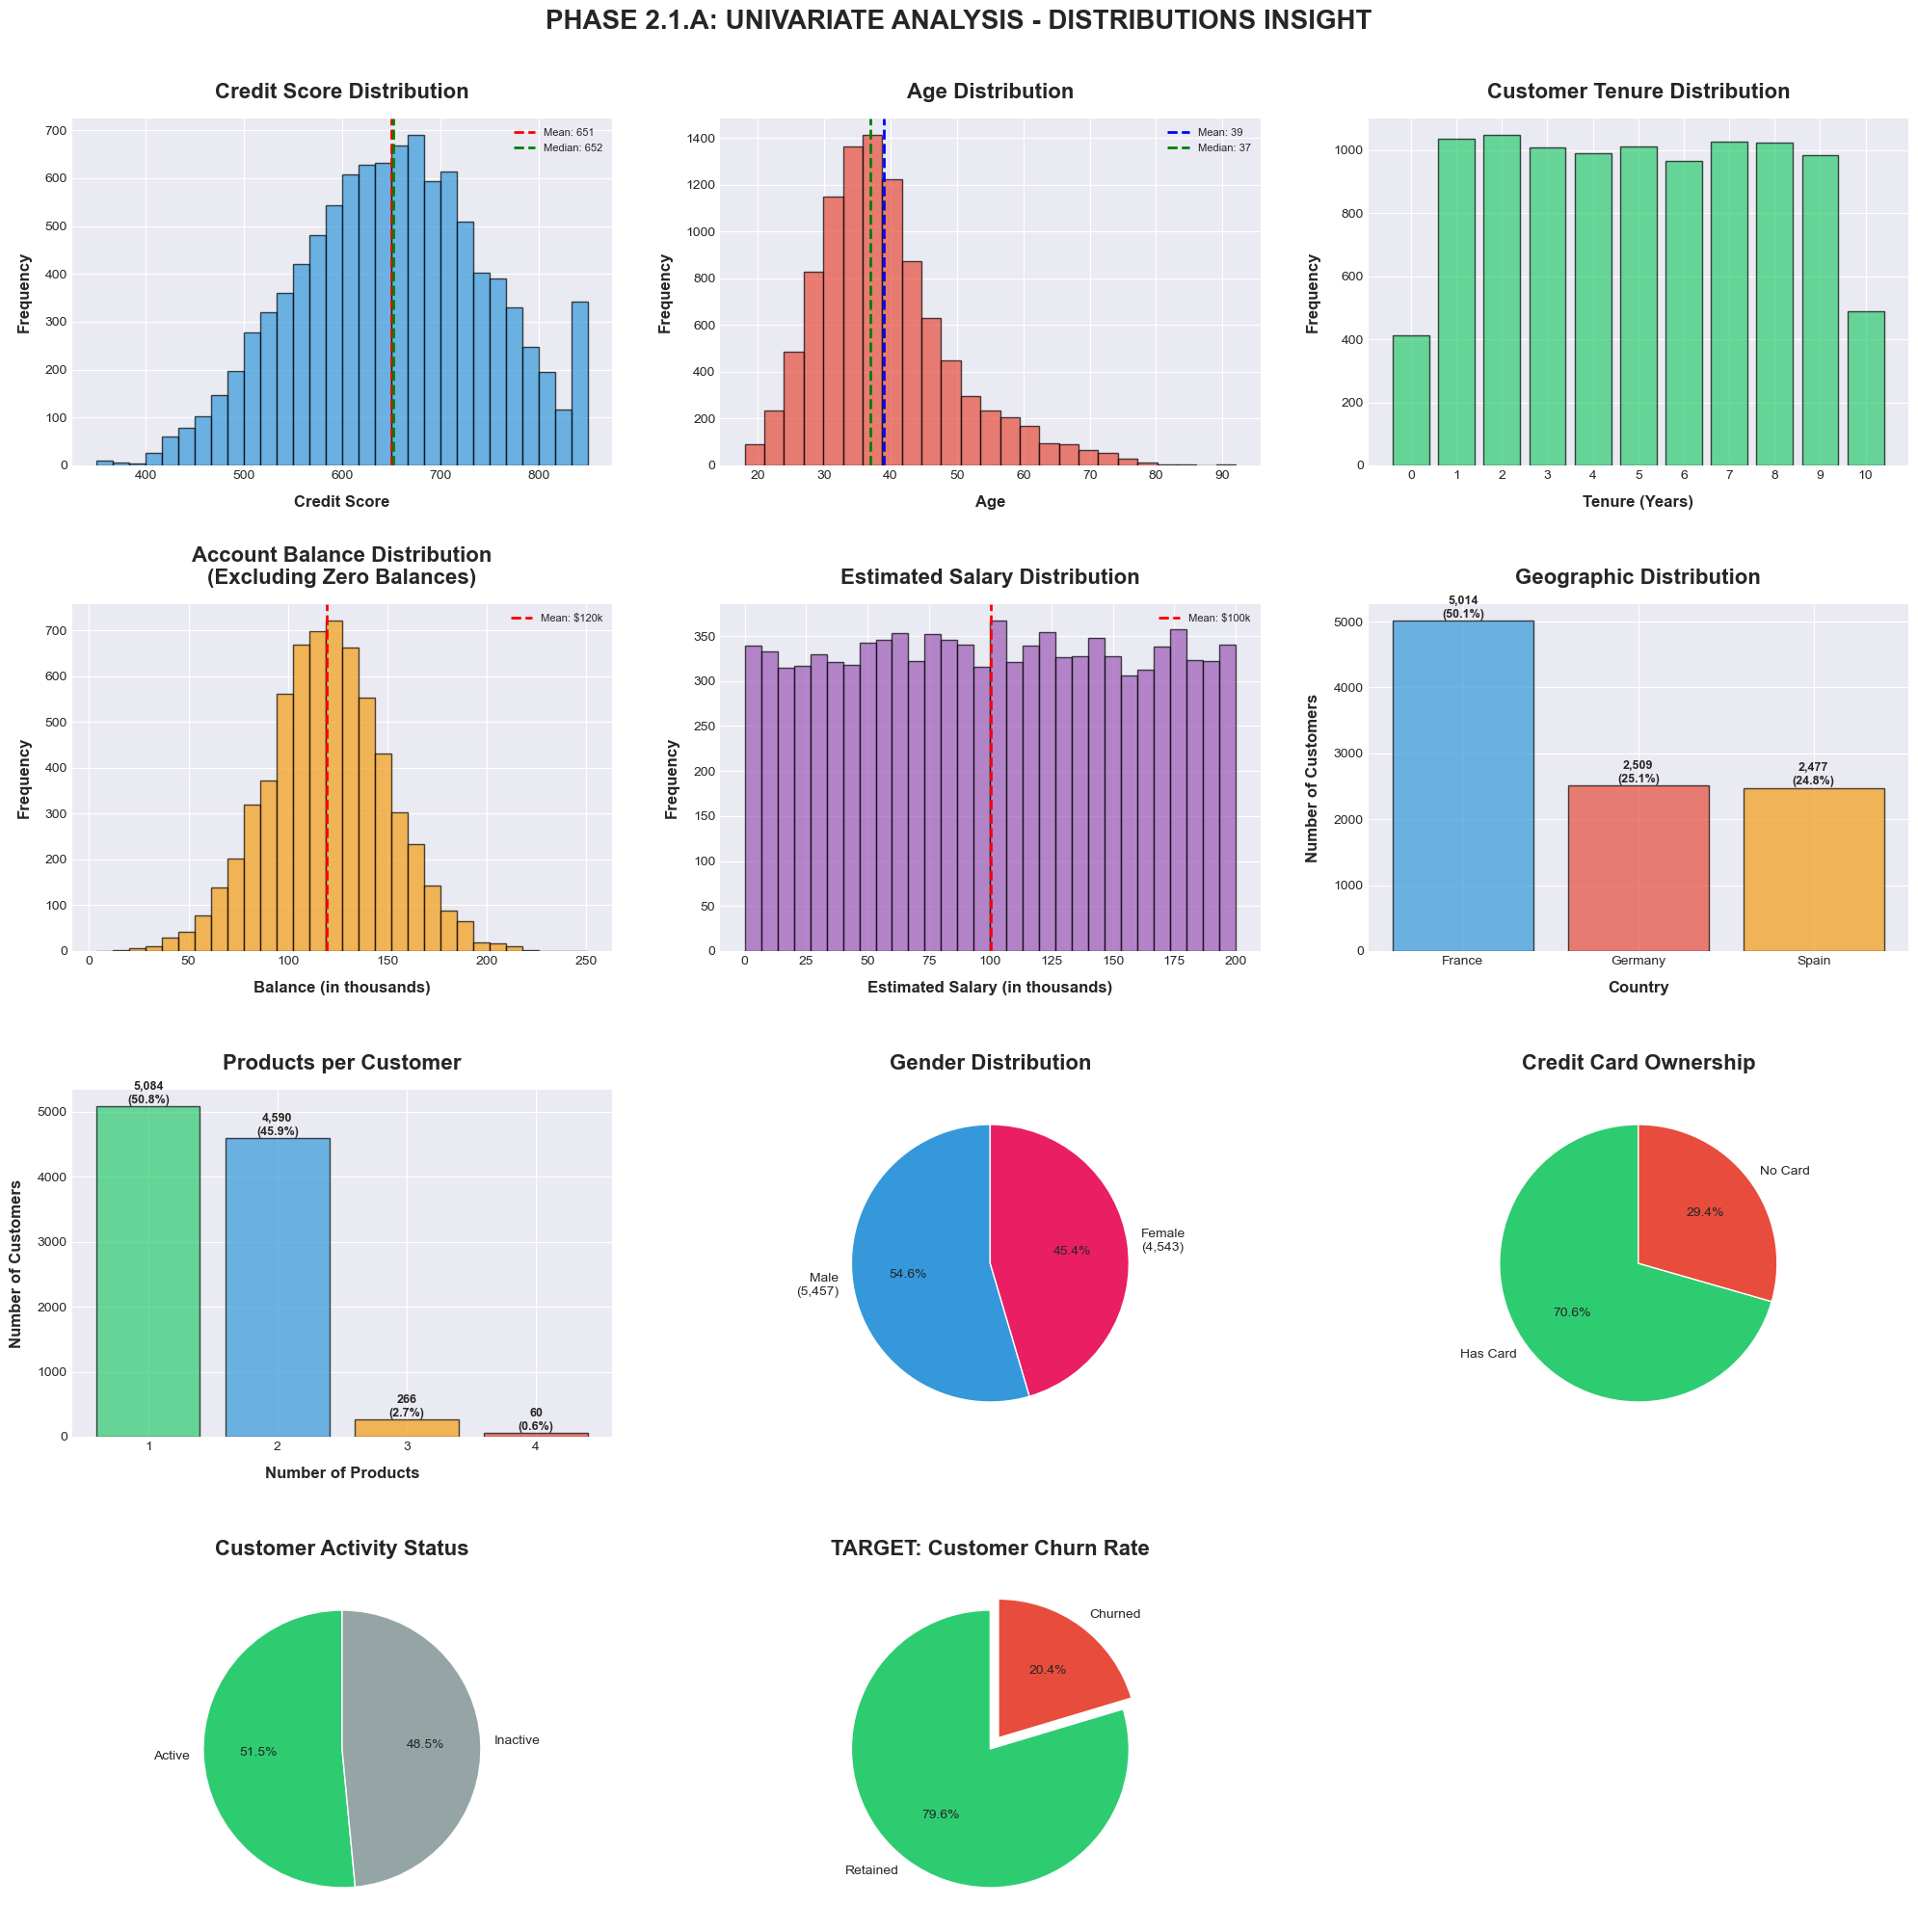


✅ Univariate Analysis Visualizations Complete!


In [29]:
# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create comprehensive univariate visualizations
fig = plt.figure(figsize=(20, 20))
fig.suptitle('PHASE 2.1.A: UNIVARIATE ANALYSIS - DISTRIBUTIONS INSIGHT', 
             fontsize=20, fontweight='bold', y=1.00)

# 1. Credit Score Distribution
ax1 = plt.subplot(4, 3, 1)
ax1.hist(df_clean['CreditScore'], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
ax1.axvline(df_clean['CreditScore'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df_clean["CreditScore"].mean():.0f}')
ax1.axvline(df_clean['CreditScore'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df_clean["CreditScore"].median():.0f}')
ax1.set_xlabel('Credit Score', fontsize=12, fontweight='bold', labelpad=10)
ax1.set_ylabel('Frequency', fontsize=12, fontweight='bold', labelpad=10)
ax1.set_title('Credit Score Distribution', fontsize=16, fontweight='bold', pad=15)
ax1.legend(fontsize=8)

# 2. Age Distribution
ax2 = plt.subplot(4, 3, 2)
ax2.hist(df_clean['Age'], bins=25, color='#e74c3c', edgecolor='black', alpha=0.7)
ax2.axvline(df_clean['Age'].mean(), color='blue', linestyle='--', linewidth=2, label=f'Mean: {df_clean["Age"].mean():.0f}')
ax2.axvline(df_clean['Age'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df_clean["Age"].median():.0f}')
ax2.set_xlabel('Age', fontsize=12, fontweight='bold', labelpad=10)
ax2.set_ylabel('Frequency', fontsize=12, fontweight='bold', labelpad=10)
ax2.set_title('Age Distribution', fontsize=16, fontweight='bold', pad=15)
ax2.legend(fontsize=8)

# 3. Tenure Distribution
ax3 = plt.subplot(4, 3, 3)
tenure_counts = df_clean['Tenure'].value_counts().sort_index()
ax3.bar(tenure_counts.index, tenure_counts.values, color='#2ecc71', edgecolor='black', alpha=0.7)
ax3.set_xlabel('Tenure (Years)', fontsize=12, fontweight='bold', labelpad=10)
ax3.set_ylabel('Frequency', fontsize=12, fontweight='bold', labelpad=10)
ax3.set_title('Customer Tenure Distribution', fontsize=16, fontweight='bold', pad=15)
ax3.set_xticks(range(11))

# 4. Balance Distribution (Non-Zero)
ax4 = plt.subplot(4, 3, 4)
balance_non_zero = df_clean[df_clean['Balance'] > 0]['Balance']
ax4.hist(balance_non_zero/1000, bins=30, color='#f39c12', edgecolor='black', alpha=0.7)
ax4.set_xlabel('Balance (in thousands)', fontsize=12, fontweight='bold', labelpad=10)
ax4.set_ylabel('Frequency', fontsize=12, fontweight='bold', labelpad=10)
ax4.set_title('Account Balance Distribution\n(Excluding Zero Balances)', fontsize=16, fontweight='bold', pad=15)
ax4.axvline(balance_non_zero.mean()/1000, color='red', linestyle='--', linewidth=2, label=f'Mean: ${balance_non_zero.mean()/1000:.0f}k')
ax4.legend(fontsize=8)

# 5. Estimated Salary Distribution
ax5 = plt.subplot(4, 3, 5)
ax5.hist(df_clean['EstimatedSalary']/1000, bins=30, color='#9b59b6', edgecolor='black', alpha=0.7)
ax5.set_xlabel('Estimated Salary (in thousands)', fontsize=12, fontweight='bold', labelpad=10)
ax5.set_ylabel('Frequency', fontsize=12, fontweight='bold', labelpad=10)
ax5.set_title('Estimated Salary Distribution', fontsize=16, fontweight='bold', pad=15)
ax5.axvline(df_clean['EstimatedSalary'].mean()/1000, color='red', linestyle='--', linewidth=2, label=f'Mean: ${df_clean["EstimatedSalary"].mean()/1000:.0f}k')
ax5.legend(fontsize=8)

# 6. Geography Distribution
ax6 = plt.subplot(4, 3, 6)
geo_counts = df_clean['Geography'].value_counts()
colors_geo = ['#3498db', '#e74c3c', '#f39c12']
bars = ax6.bar(geo_counts.index, geo_counts.values, color=colors_geo, edgecolor='black', alpha=0.7)
ax6.set_xlabel('Country', fontsize=12, fontweight='bold', labelpad=10)
ax6.set_ylabel('Number of Customers', fontsize=12, fontweight='bold', labelpad=10)
ax6.set_title('Geographic Distribution', fontsize=16, fontweight='bold', pad=15)
for bar, val in zip(bars, geo_counts.values):
    ax6.text(bar.get_x() + bar.get_width()/2, val + 50, f'{val:,}\n({val/len(df_clean)*100:.1f}%)', 
             ha='center', fontsize=9, fontweight='bold')

# 7. Gender Distribution
ax7 = plt.subplot(4, 3, 8)
gender_counts = df_clean['Gender'].value_counts()
colors_gender = ['#3498db', '#e91e63']
wedges, texts, autotexts = ax7.pie(gender_counts.values, 
                                    labels=[f'{g}\n({gender_counts[g]:,})' for g in gender_counts.index],
                                    colors=colors_gender,
                                    autopct='%1.1f%%',
                                    startangle=90)
ax7.set_title('Gender Distribution', fontsize=16, fontweight='bold', pad=15)

# 8. Number of Products
ax8 = plt.subplot(4, 3, 7)
products_counts = df_clean['NumOfProducts'].value_counts().sort_index()
colors_prod = ['#2ecc71', '#3498db', '#f39c12', '#e74c3c']
bars = ax8.bar(products_counts.index, products_counts.values, 
               color=colors_prod[:len(products_counts)], edgecolor='black', alpha=0.7)
ax8.set_xlabel('Number of Products', fontsize=12, fontweight='bold', labelpad=10)
ax8.set_ylabel('Number of Customers', fontsize=12, fontweight='bold', labelpad=10)
ax8.set_title('Products per Customer', fontsize=16, fontweight='bold', pad=15)
ax8.set_xticks(products_counts.index)
for bar, val in zip(bars, products_counts.values):
    ax8.text(bar.get_x() + bar.get_width()/2, val + 50, f'{val:,}\n({val/len(df_clean)*100:.1f}%)', 
             ha='center', fontsize=9, fontweight='bold')

# 9. Has Credit Card
ax9 = plt.subplot(4, 3, 9)
card_counts = df_clean['HasCrCard'].value_counts()
colors_card = ['#e74c3c', '#2ecc71']
wedges, texts, autotexts = ax9.pie(card_counts.values, 
                                   labels=['Has Card', 'No Card'],
                                   colors=colors_card[::-1],
                                   autopct='%1.1f%%',
                                   startangle=90)
ax9.set_title('Credit Card Ownership', fontsize=16, fontweight='bold', pad=15)

# 10. Is Active Member
ax10 = plt.subplot(4, 3, 10)
active_counts = df_clean['IsActiveMember'].value_counts()
colors_active = ['#95a5a6', '#2ecc71']
wedges, texts, autotexts = ax10.pie(active_counts.values, 
                                    labels=['Active', 'Inactive'],
                                    colors=colors_active[::-1],
                                    autopct='%1.1f%%',
                                    startangle=90)

ax10.set_title('Customer Activity Status', fontsize=16, fontweight='bold', pad=15)

# 11. Churn Distribution
ax11 = plt.subplot(4, 3, 11)
churn_counts = df_clean['Exited'].value_counts()
colors_churn = ['#2ecc71', '#e74c3c']
wedges, texts, autotexts = ax11.pie(churn_counts.values, 
                                    labels=['Retained', 'Churned'],
                                    colors=colors_churn,
                                    autopct='%1.1f%%',
                                    startangle=90,
                                    explode=(0, 0.1))
ax11.set_title('TARGET: Customer Churn Rate', fontsize=16, fontweight='bold', pad=15)



fig.tight_layout(rect=[0, 0, 1, .99])   # leaves top 1% for the suptitle
fig.subplots_adjust(hspace=0.4, wspace=0.2)  # add extra vertical/horizontal padding
plt.show()

print("\n✅ Univariate Analysis Visualizations Complete!")

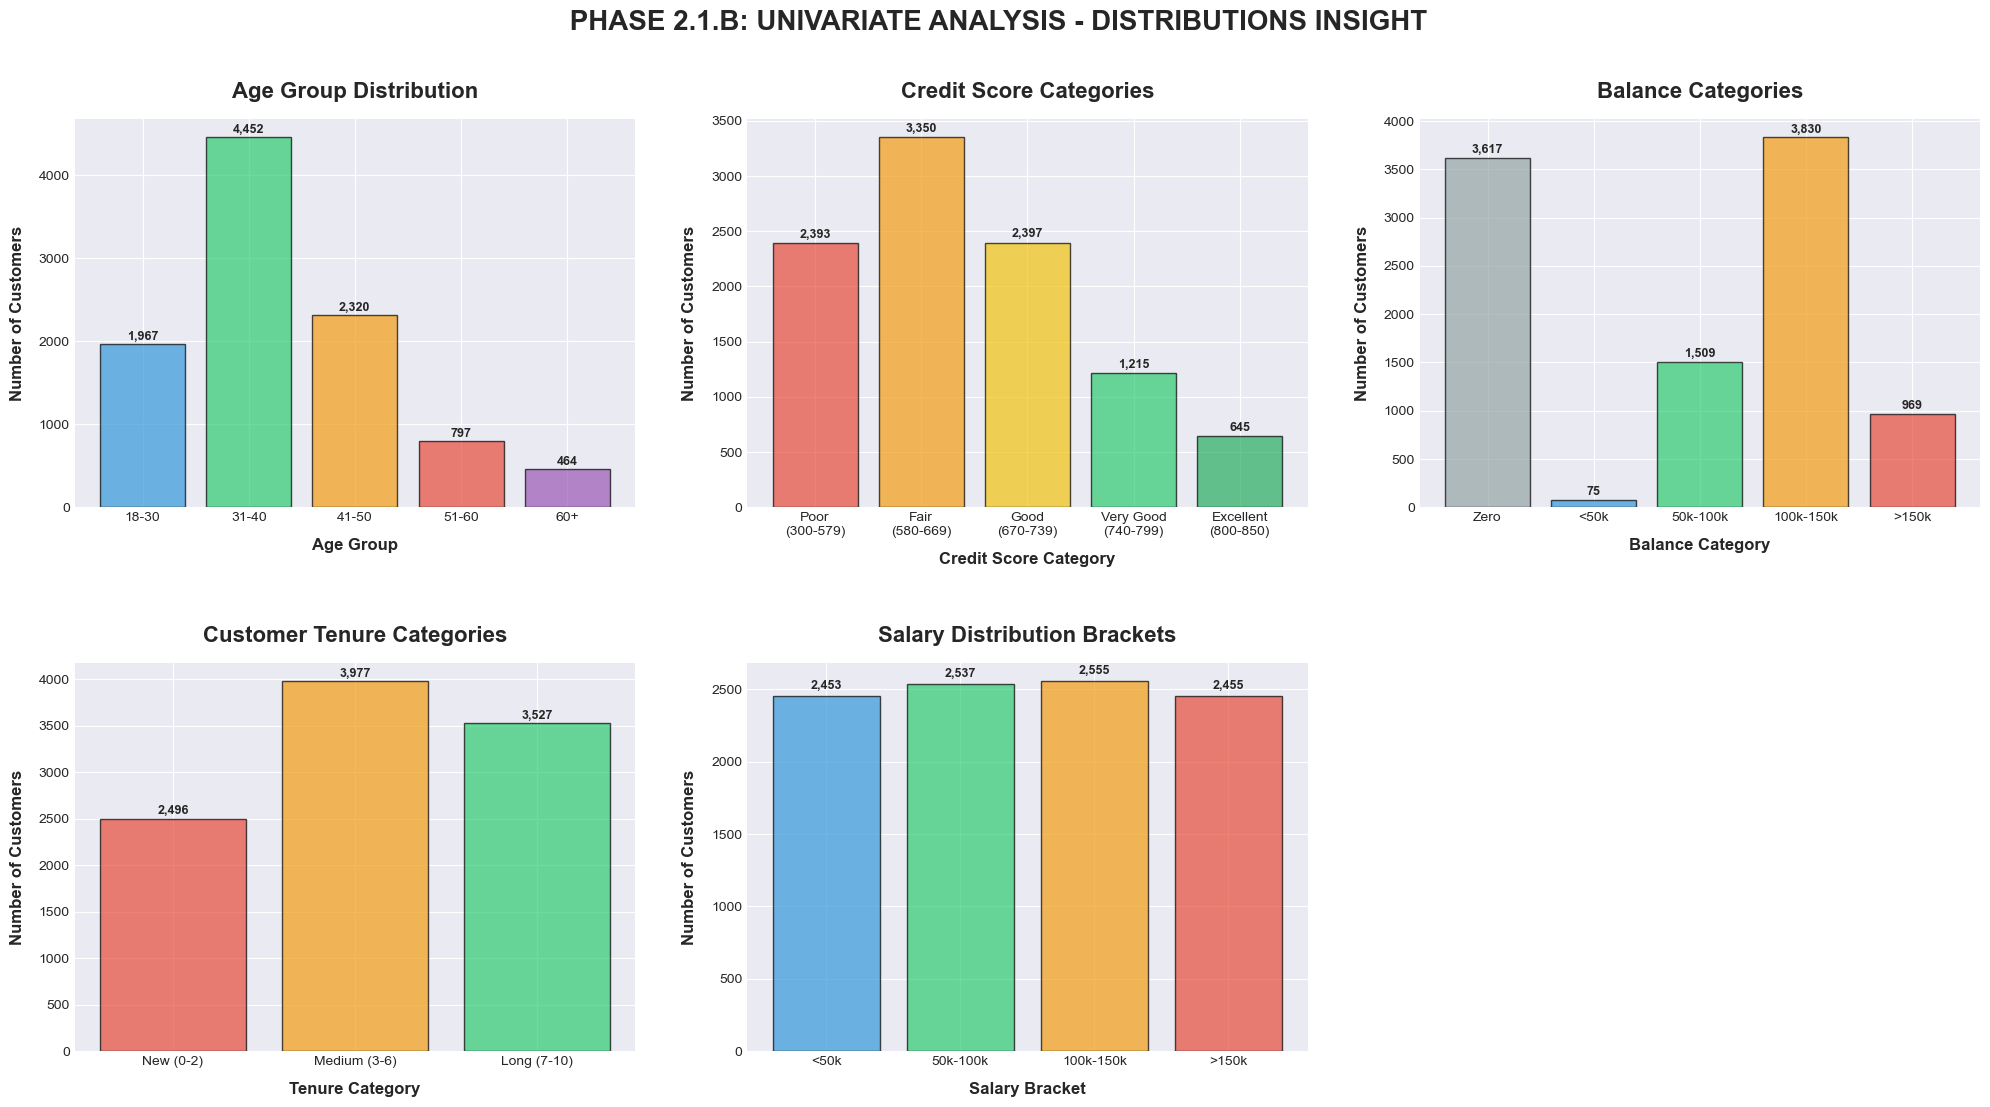

In [30]:
# Create comprehensive univariate visualizations
fig = plt.figure(figsize=(20, 16))
fig.suptitle(' PHASE 2.1.B: UNIVARIATE ANALYSIS - DISTRIBUTIONS INSIGHT', 
             fontsize=20, fontweight='bold', y=1.00)

# 12. Age Groups
ax12 = plt.subplot(3, 3, 1)
age_groups = pd.cut(df_clean['Age'], bins=[0, 30, 40, 50, 60, 100], 
                    labels=['18-30', '31-40', '41-50', '51-60', '60+'])
age_group_counts = age_groups.value_counts().sort_index()
colors_age = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c', '#9b59b6']
bars = ax12.bar(age_group_counts.index, age_group_counts.values, 
                color=colors_age, edgecolor='black', alpha=0.7)
ax12.set_xlabel('Age Group', fontsize=12, fontweight='bold', labelpad=10)
ax12.set_ylabel('Number of Customers', fontsize=12, fontweight='bold', labelpad=10)
ax12.set_title('Age Group Distribution', fontsize=16, fontweight='bold', pad=15)
for bar, val in zip(bars, age_group_counts.values):
    ax12.text(bar.get_x() + bar.get_width()/2, val + 50, f'{val:,}', 
             ha='center', fontsize=9, fontweight='bold')

# 13. Credit Score Categories
ax13 = plt.subplot(3, 3, 2)
credit_categories = pd.cut(df_clean['CreditScore'], 
                          bins=[0, 580, 670, 740, 800, 850],
                          labels=['Poor\n(300-579)', 'Fair\n(580-669)', 'Good\n(670-739)', 
                                  'Very Good\n(740-799)', 'Excellent\n(800-850)'])
credit_cat_counts = credit_categories.value_counts().sort_index()
colors_credit = ['#e74c3c', '#f39c12', '#f1c40f', '#2ecc71', '#27ae60']
bars = ax13.bar(range(len(credit_cat_counts)), credit_cat_counts.values, 
                color=colors_credit, edgecolor='black', alpha=0.7)
ax13.set_xlabel('Credit Score Category', fontsize=12, fontweight='bold', labelpad=10)
ax13.set_ylabel('Number of Customers', fontsize=12, fontweight='bold', labelpad=10)
ax13.set_title('Credit Score Categories', fontsize=16, fontweight='bold', pad=15)
ax13.set_xticks(range(len(credit_cat_counts)))
ax13.set_xticklabels(credit_cat_counts.index, ha='center')
for i, val in enumerate(credit_cat_counts.values):
    ax13.text(i, val + 50, f'{val:,}', ha='center', fontsize=9, fontweight='bold')

# 14. Balance Categories
ax14 = plt.subplot(3, 3, 3)
balance_categories = ['Zero', '<50k', '50k-100k', '100k-150k', '>150k']
balance_counts = [
    (df_clean['Balance'] == 0).sum(),
    (df_clean['Balance'].between(0.01, 50000)).sum(),
    (df_clean['Balance'].between(50000, 100000)).sum(),
    (df_clean['Balance'].between(100000, 150000)).sum(),
    (df_clean['Balance'] > 150000).sum()
]
colors_balance = ['#95a5a6', '#3498db', '#2ecc71', '#f39c12', '#e74c3c']
bars = ax14.bar(balance_categories, balance_counts, color=colors_balance, edgecolor='black', alpha=0.7)
ax14.set_xlabel('Balance Category', fontsize=12, fontweight='bold', labelpad=10)
ax14.set_ylabel('Number of Customers', fontsize=12, fontweight='bold', labelpad=10)
ax14.set_title('Balance Categories', fontsize=16, fontweight='bold', pad=15)
ax14.set_xticklabels(balance_categories, ha='center')
for bar, val in zip(bars, balance_counts):
    ax14.text(bar.get_x() + bar.get_width()/2, val + 50, f'{val:,}', 
             ha='center', fontsize=9, fontweight='bold')

# 15. Tenure Categories
ax15 = plt.subplot(3, 3, 4)
tenure_categories = ['New (0-2)', 'Medium (3-6)', 'Long (7-10)']
tenure_cat_counts = [
    (df_clean['Tenure'] <= 2).sum(),
    (df_clean['Tenure'].between(3, 6)).sum(),
    (df_clean['Tenure'] >= 7).sum()
]
colors_tenure = ['#e74c3c', '#f39c12', '#2ecc71']
bars = ax15.bar(tenure_categories, tenure_cat_counts, color=colors_tenure, edgecolor='black', alpha=0.7)
ax15.set_xlabel('Tenure Category', fontsize=12, fontweight='bold', labelpad=10)
ax15.set_ylabel('Number of Customers', fontsize=12, fontweight='bold', labelpad=10)
ax15.set_title('Customer Tenure Categories', fontsize=16, fontweight='bold', pad=15)
for bar, val in zip(bars, tenure_cat_counts):
    ax15.text(bar.get_x() + bar.get_width()/2, val + 50, f'{val:,}', 
             ha='center', fontsize=9, fontweight='bold')

# 16. Salary Brackets
ax16 = plt.subplot(3, 3, 5)
salary_brackets = pd.cut(df_clean['EstimatedSalary'], 
                         bins=[0, 50000, 100000, 150000, 200000],
                         labels=['<50k', '50k-100k', '100k-150k', '>150k'])
salary_counts = salary_brackets.value_counts().sort_index()
colors_salary = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']
bars = ax16.bar(salary_counts.index, salary_counts.values, color=colors_salary, edgecolor='black', alpha=0.7)
ax16.set_xlabel('Salary Bracket', fontsize=12, fontweight='bold', labelpad=10)
ax16.set_ylabel('Number of Customers', fontsize=12, fontweight='bold', labelpad=10)
ax16.set_title('Salary Distribution Brackets', fontsize=16, fontweight='bold', pad=15)
for bar, val in zip(bars, salary_counts.values):
    ax16.text(bar.get_x() + bar.get_width()/2, val + 50, f'{val:,}', 
             ha='center', fontsize=9, fontweight='bold')

fig.tight_layout(rect=[0, 0, 1, .99])   # leaves top 2% for the suptitle
fig.subplots_adjust(hspace=0.4, wspace=0.2)  # add extra vertical/horizontal padding
plt.show()

### 🔗 2.2 Bivariate Analysis
- Churn rate analysis by each feature
- Correlation matrix for numerical variables
- Cross-tabulation for categorical variables
- Comparative analysis (churned vs retained customers)


In [31]:
print("\n" + "="*50)
print("📊 2.2 BIVARIATE ANALYSIS")
print("="*50)

print("\n" + "-"*40)
print("🎯 CHURN RATE ANALYSIS BY FEATURES")
print("-"*40)

# Overall churn rate
overall_churn_rate = df_clean['Exited'].mean() * 100
print(f"\n📌 Overall Churn Rate: {overall_churn_rate:.2f}%")
print(f"   • Churned Customers: {df_clean['Exited'].sum():,}")
print(f"   • Retained Customers: {(df_clean['Exited'] == 0).sum():,}")


📊 2.2 BIVARIATE ANALYSIS

----------------------------------------
🎯 CHURN RATE ANALYSIS BY FEATURES
----------------------------------------

📌 Overall Churn Rate: 20.37%
   • Churned Customers: 2,037
   • Retained Customers: 7,963


In [32]:
print("\n" + "="*40)
print("1️⃣ CATEGORICAL FEATURES vs CHURN")
print("="*40)

# Geography vs Churn
print("\n📍 Geography vs Churn:")
print("-" * 30)
geo_churn = df_clean.groupby('Geography')['Exited'].agg(['sum', 'count', 'mean'])
geo_churn.columns = ['Churned', 'Total', 'Churn_Rate']
geo_churn['Retained'] = geo_churn['Total'] - geo_churn['Churned']
geo_churn['Churn_Rate_Pct'] = geo_churn['Churn_Rate'] * 100
print(geo_churn[['Total', 'Churned', 'Retained', 'Churn_Rate_Pct']].to_string())
print(f"\n   🔍 Insight: Germany has the highest churn rate ({geo_churn.loc['Germany', 'Churn_Rate_Pct']:.1f}%)")

# Gender vs Churn
print("\n👥 Gender vs Churn:")
print("-" * 30)
gender_churn = df_clean.groupby('Gender')['Exited'].agg(['sum', 'count', 'mean'])
gender_churn.columns = ['Churned', 'Total', 'Churn_Rate']
gender_churn['Retained'] = gender_churn['Total'] - gender_churn['Churned']
gender_churn['Churn_Rate_Pct'] = gender_churn['Churn_Rate'] * 100
print(gender_churn[['Total', 'Churned', 'Retained', 'Churn_Rate_Pct']].to_string())
print(f"\n   🔍 Insight: Females have higher churn rate ({gender_churn.loc['Female', 'Churn_Rate_Pct']:.1f}%) than Males ({gender_churn.loc['Male', 'Churn_Rate_Pct']:.1f}%)")

# Number of Products vs Churn
print("\n📦 Number of Products vs Churn:")
print("-" * 30)
products_churn = df_clean.groupby('NumOfProducts')['Exited'].agg(['sum', 'count', 'mean'])
products_churn.columns = ['Churned', 'Total', 'Churn_Rate']
products_churn['Retained'] = products_churn['Total'] - products_churn['Churned']
products_churn['Churn_Rate_Pct'] = products_churn['Churn_Rate'] * 100
print(products_churn[['Total', 'Churned', 'Retained', 'Churn_Rate_Pct']].to_string())
print(f"\n   🔍 Insight: Customers with 3-4 products have extremely high churn rates!")

# Has Credit Card vs Churn
print("\n💳 Credit Card Ownership vs Churn:")
print("-" * 30)
card_churn = df_clean.groupby('HasCrCard')['Exited'].agg(['sum', 'count', 'mean'])
card_churn.columns = ['Churned', 'Total', 'Churn_Rate']
card_churn['Retained'] = card_churn['Total'] - card_churn['Churned']
card_churn['Churn_Rate_Pct'] = card_churn['Churn_Rate'] * 100
card_churn.index = ['No Card', 'Has Card']
print(card_churn[['Total', 'Churned', 'Retained', 'Churn_Rate_Pct']].to_string())
print(f"\n   🔍 Insight: Credit card ownership shows minimal impact on churn")

# Is Active Member vs Churn
print("\n🏃 Activity Status vs Churn:")
print("-" * 30)
active_churn = df_clean.groupby('IsActiveMember')['Exited'].agg(['sum', 'count', 'mean'])
active_churn.columns = ['Churned', 'Total', 'Churn_Rate']
active_churn['Retained'] = active_churn['Total'] - active_churn['Churned']
active_churn['Churn_Rate_Pct'] = active_churn['Churn_Rate'] * 100
active_churn.index = ['Inactive', 'Active']
print(active_churn[['Total', 'Churned', 'Retained', 'Churn_Rate_Pct']].to_string())
print(f"\n   🔍 Insight: Inactive members have significantly higher churn rate ({active_churn.loc['Inactive', 'Churn_Rate_Pct']:.1f}%)")


1️⃣ CATEGORICAL FEATURES vs CHURN

📍 Geography vs Churn:
------------------------------
           Total  Churned  Retained  Churn_Rate_Pct
Geography                                          
France      5014      810      4204           16.15
Germany     2509      814      1695           32.44
Spain       2477      413      2064           16.67

   🔍 Insight: Germany has the highest churn rate (32.4%)

👥 Gender vs Churn:
------------------------------
        Total  Churned  Retained  Churn_Rate_Pct
Gender                                          
Female   4543     1139      3404           25.07
Male     5457      898      4559           16.46

   🔍 Insight: Females have higher churn rate (25.1%) than Males (16.5%)

📦 Number of Products vs Churn:
------------------------------
               Total  Churned  Retained  Churn_Rate_Pct
NumOfProducts                                          
1               5084     1409      3675           27.71
2               4590      348      4242   

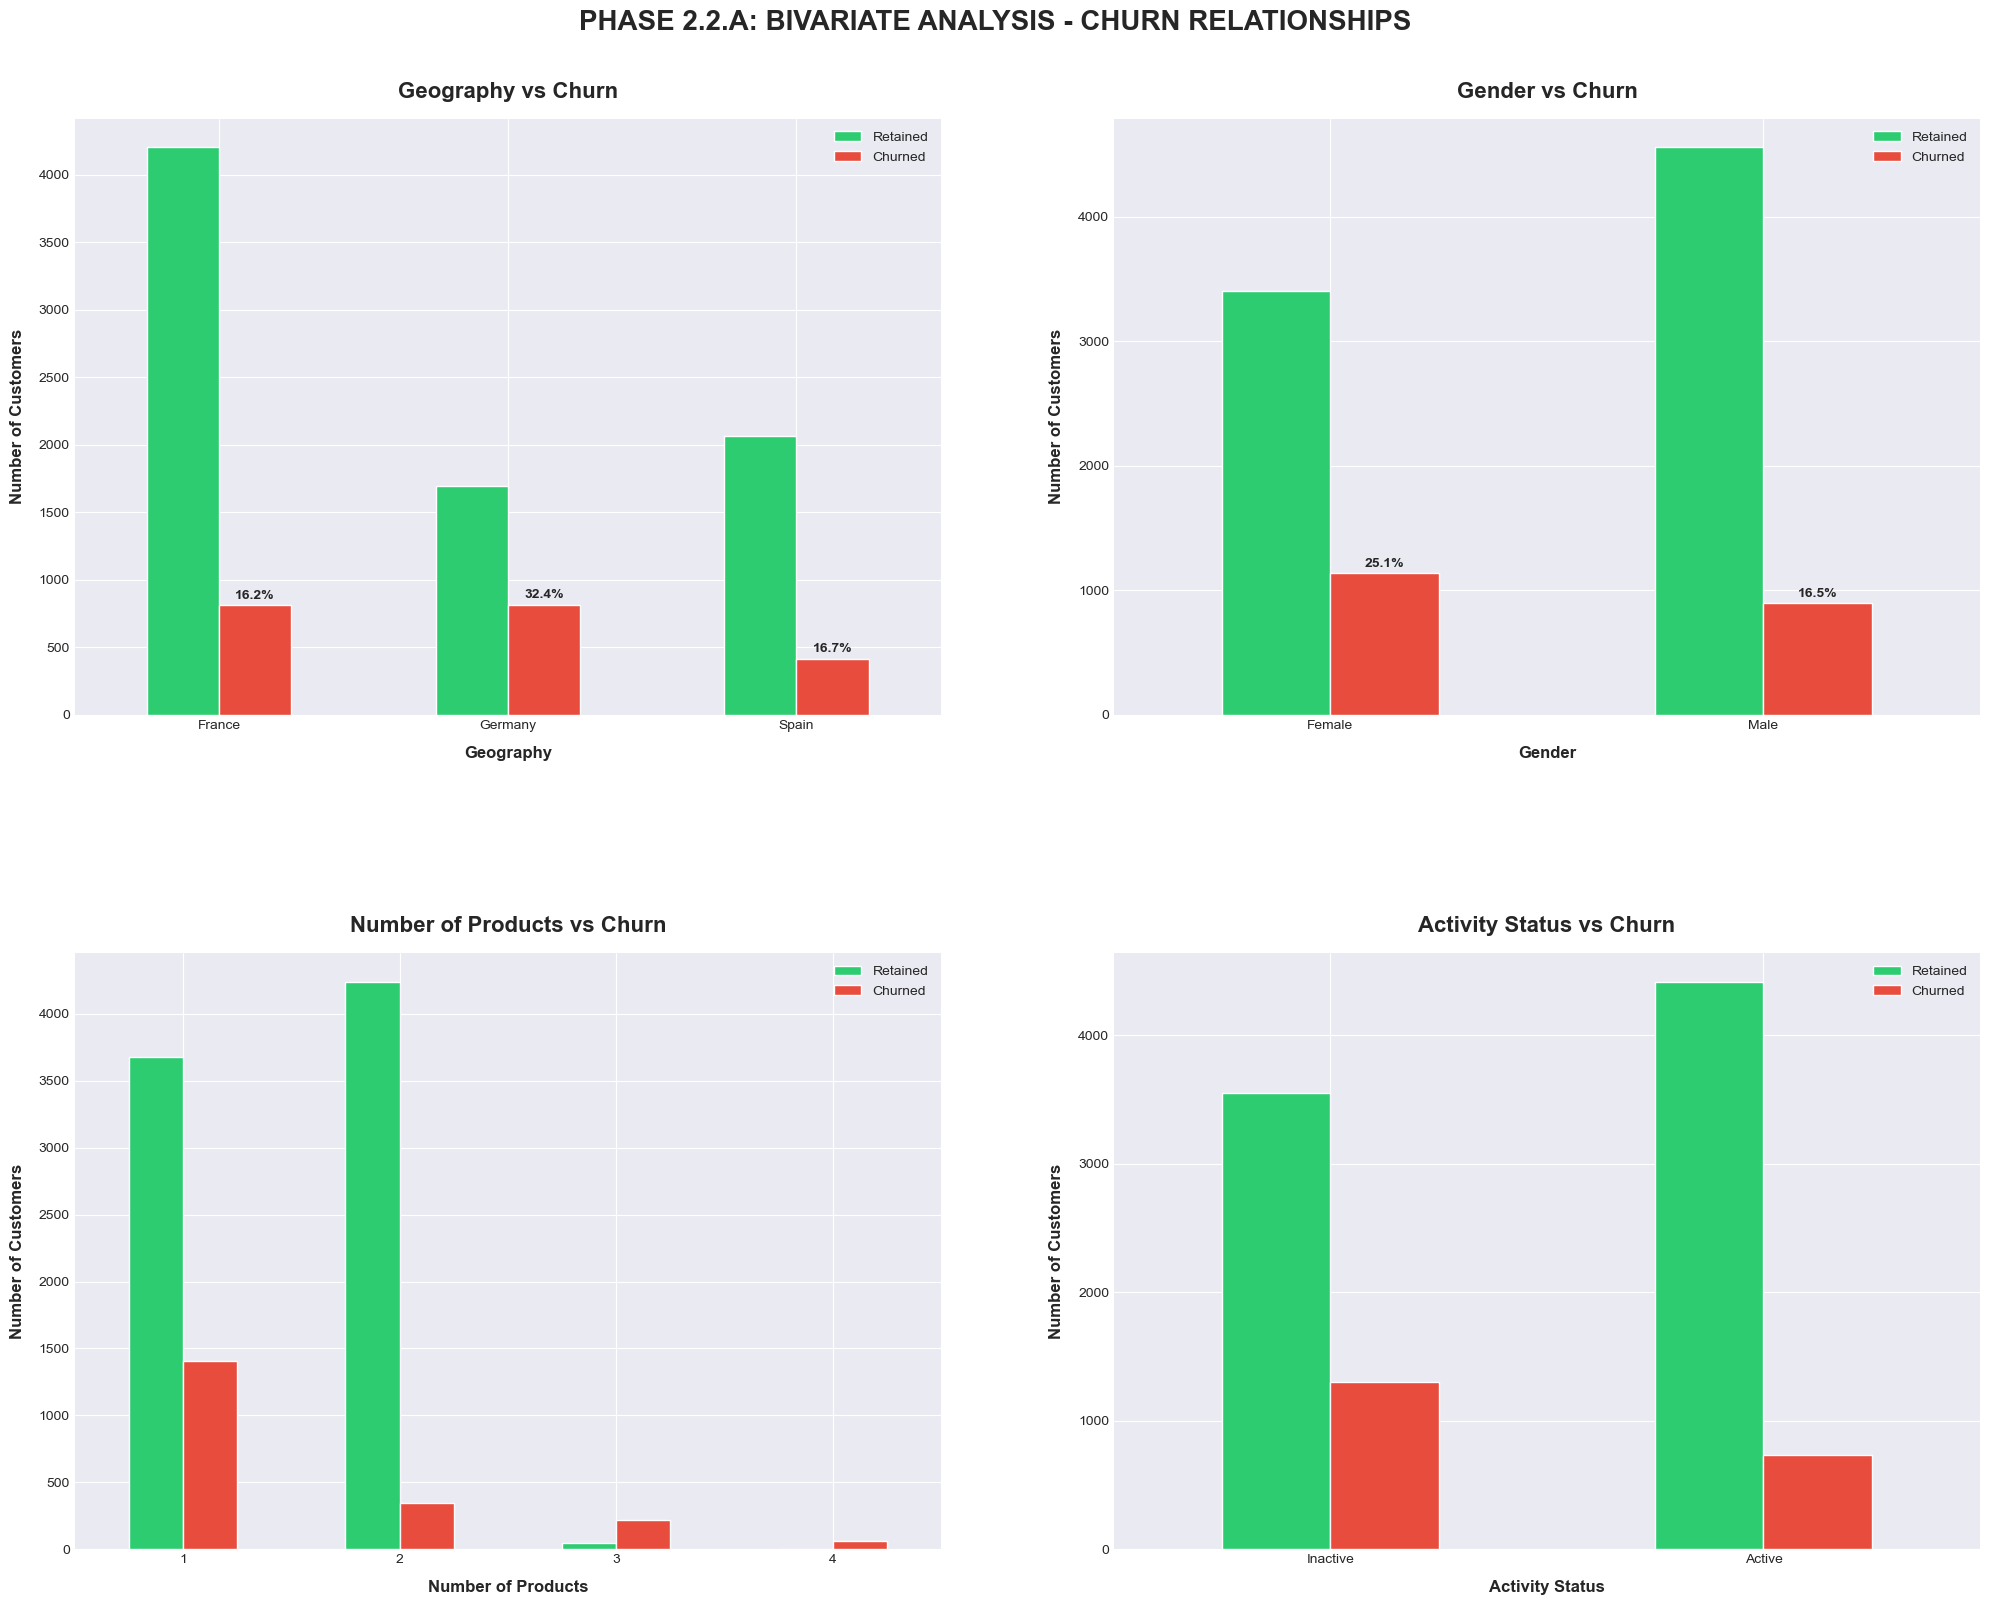

In [33]:
# Create comprehensive bivariate visualizations
fig = plt.figure(figsize=(20, 16))
fig.suptitle('PHASE 2.2.A: BIVARIATE ANALYSIS - CHURN RELATIONSHIPS', 
             fontsize=20, fontweight='bold', y=1.00)

# 1. Geography vs Churn
ax1 = plt.subplot(2, 2, 1)
geo_churn_data = df_clean.groupby(['Geography', 'Exited']).size().unstack()
geo_churn_data.plot(kind='bar', stacked=False, ax=ax1, color=['#2ecc71', '#e74c3c'])
ax1.set_xlabel('Geography', fontsize=12, fontweight='bold', labelpad=10)
ax1.set_ylabel('Number of Customers', fontsize=12, fontweight='bold', labelpad=10)
ax1.set_title('Geography vs Churn', fontsize=16, fontweight='bold', pad=15)
ax1.legend(['Retained', 'Churned'])
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)

# Add churn rate text on top of red bars (churned)
geo_churn_rate = df_clean.groupby('Geography')['Exited'].mean()
# Get the red bars (second set of bars)
red_bars = [p for p in ax1.patches if p.get_facecolor()[0] > 0.8]  # Red bars have high R value
for bar, (country, rate) in zip(red_bars, geo_churn_rate.items()):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 50, f'{rate*100:.1f}%', 
             ha='center', fontweight='bold', fontsize=10)

# 2. Gender vs Churn
ax2 = plt.subplot(2, 2, 2)
gender_churn_data = df_clean.groupby(['Gender', 'Exited']).size().unstack()
gender_churn_data.plot(kind='bar', stacked=False, ax=ax2, color=['#2ecc71', '#e74c3c'])
ax2.set_xlabel('Gender', fontsize=12, fontweight='bold', labelpad=10)
ax2.set_ylabel('Number of Customers', fontsize=12, fontweight='bold', labelpad=10)
ax2.set_title('Gender vs Churn', fontsize=16, fontweight='bold', pad=15)
ax2.legend(['Retained', 'Churned'])
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)

# Add churn rate text on top of red bars (churned)
gender_churn_rate = df_clean.groupby('Gender')['Exited'].mean()
# Get the red bars (second set of bars)
red_bars = [p for p in ax2.patches if p.get_facecolor()[0] > 0.8]  # Red bars have high R value
for bar, (gender, rate) in zip(red_bars, gender_churn_rate.items()):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, height + 50, f'{rate*100:.1f}%', 
             ha='center', fontweight='bold', fontsize=10)

# 3. Number of Products vs Churn
ax3 = plt.subplot(2, 2, 3)
products_churn_data = df_clean.groupby(['NumOfProducts', 'Exited']).size().unstack(fill_value=0)
products_churn_data.plot(kind='bar', stacked=False, ax=ax3, color=['#2ecc71', '#e74c3c'])
ax3.set_xlabel('Number of Products', fontsize=12, fontweight='bold', labelpad=10)
ax3.set_ylabel('Number of Customers', fontsize=12, fontweight='bold', labelpad=10)
ax3.set_title('Number of Products vs Churn', fontsize=16, fontweight='bold', pad=15)
ax3.legend(['Retained', 'Churned'])
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=0)

# 4. Activity Status vs Churn
ax4 = plt.subplot(2, 2, 4)
active_churn_data = df_clean.groupby(['IsActiveMember', 'Exited']).size().unstack()
active_churn_data.index = ['Inactive', 'Active']
active_churn_data.plot(kind='bar', stacked=False, ax=ax4, color=['#2ecc71', '#e74c3c'])
ax4.set_xlabel('Activity Status', fontsize=12, fontweight='bold', labelpad=10)
ax4.set_ylabel('Number of Customers', fontsize=12, fontweight='bold', labelpad=10)
ax4.set_title('Activity Status vs Churn', fontsize=16, fontweight='bold', pad=15)
ax4.legend(['Retained', 'Churned'])
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=0)

fig.tight_layout(rect=[0, 0, 1, .99])   # leaves top 1% for the suptitle
fig.subplots_adjust(hspace=0.4, wspace=0.2)  # add extra vertical/horizontal padding
plt.show()

In [34]:
print("\n" + "="*40)
print("2️⃣ NUMERICAL FEATURES vs CHURN")
print("="*40)

# Compare numerical features between churned and retained
print("\n📊 Numerical Features Comparison (Churned vs Retained):")
print("-" * 50)

numerical_features = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']

comparison_data = []
for feature in numerical_features:
    churned_stats = df_clean[df_clean['Exited'] == 1][feature].describe()
    retained_stats = df_clean[df_clean['Exited'] == 0][feature].describe()
    
    comparison_data.append({
        'Feature': feature,
        'Churned_Mean': churned_stats['mean'],
        'Retained_Mean': retained_stats['mean'],
        'Difference': churned_stats['mean'] - retained_stats['mean'],
        'Diff_Pct': ((churned_stats['mean'] - retained_stats['mean']) / retained_stats['mean'] * 100) if retained_stats['mean'] != 0 else 0,
        'Churned_Median': churned_stats['50%'],
        'Retained_Median': retained_stats['50%']
    })

comparison_df = pd.DataFrame(comparison_data)
print("\nMean Comparison:")
print("-" * 30)
for _, row in comparison_df.iterrows():
    print(f"\n📌 {row['Feature']}:")
    print(f"   • Churned Mean  : {row['Churned_Mean']:,.2f}")
    print(f"   • Retained Mean : {row['Retained_Mean']:,.2f}")
    print(f"   • Difference    : {row['Difference']:,.2f} ({row['Diff_Pct']:+.1f}%)")
    
    # Add insights
    if row['Feature'] == 'Age':
        print(f"   🔍 Churned customers are older on average")
    elif row['Feature'] == 'Balance':
        print(f"   🔍 Churned customers have higher average balance")
    elif row['Feature'] == 'Tenure':
        print(f"   🔍 Churned customers have slightly lower tenure")


2️⃣ NUMERICAL FEATURES vs CHURN

📊 Numerical Features Comparison (Churned vs Retained):
--------------------------------------------------

Mean Comparison:
------------------------------

📌 CreditScore:
   • Churned Mean  : 645.35
   • Retained Mean : 651.85
   • Difference    : -6.50 (-1.0%)

📌 Age:
   • Churned Mean  : 44.84
   • Retained Mean : 37.41
   • Difference    : 7.43 (+19.9%)
   🔍 Churned customers are older on average

📌 Tenure:
   • Churned Mean  : 4.93
   • Retained Mean : 5.03
   • Difference    : -0.10 (-2.0%)
   🔍 Churned customers have slightly lower tenure

📌 Balance:
   • Churned Mean  : 91,108.54
   • Retained Mean : 72,745.30
   • Difference    : 18,363.24 (+25.2%)
   🔍 Churned customers have higher average balance

📌 EstimatedSalary:
   • Churned Mean  : 101,465.68
   • Retained Mean : 99,738.39
   • Difference    : 1,727.29 (+1.7%)


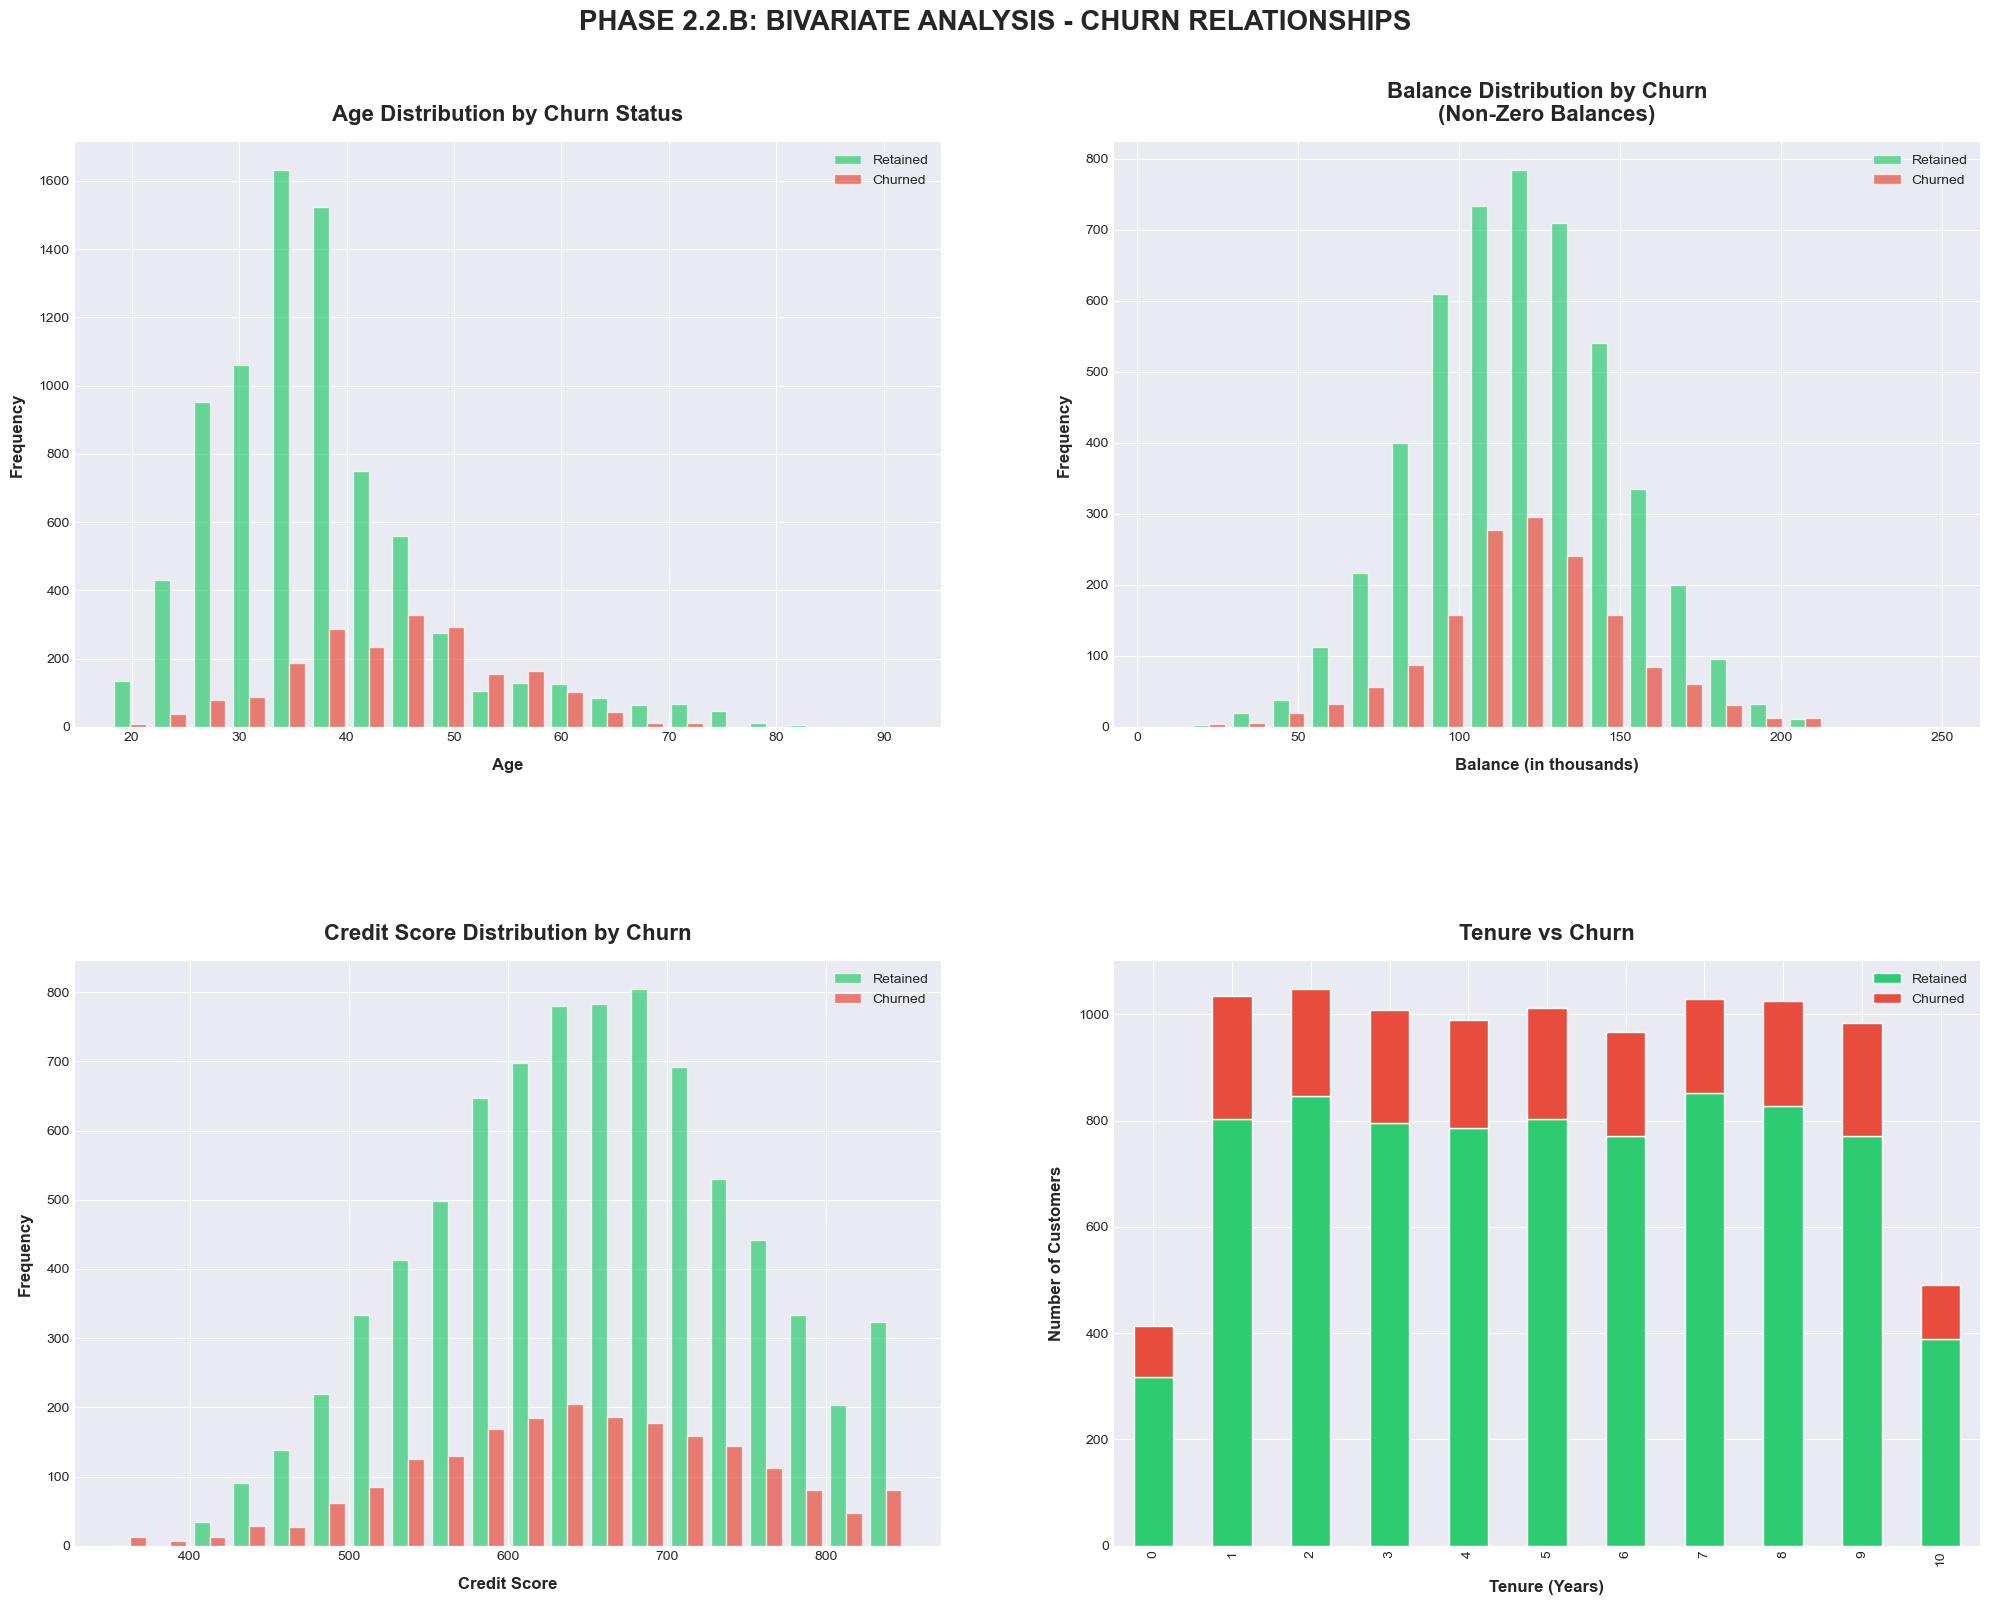

In [35]:
# Create comprehensive bivariate visualizations
fig = plt.figure(figsize=(20, 16))
fig.suptitle('PHASE 2.2.B: BIVARIATE ANALYSIS - CHURN RELATIONSHIPS', 
             fontsize=20, fontweight='bold', y=1.00)

# 5. Age Distribution by Churn
ax5 = plt.subplot(2, 2, 1)
churned_age = df_clean[df_clean['Exited'] == 1]['Age']
retained_age = df_clean[df_clean['Exited'] == 0]['Age']
ax5.hist([retained_age, churned_age], bins=20, label=['Retained', 'Churned'], 
         color=['#2ecc71', '#e74c3c'], alpha=0.7)
ax5.set_xlabel('Age', fontsize=12, fontweight='bold', labelpad=10)
ax5.set_ylabel('Frequency', fontsize=12, fontweight='bold', labelpad=10)
ax5.set_title('Age Distribution by Churn Status', fontsize=16, fontweight='bold', pad=15)
ax5.legend()

# 6. Balance Distribution by Churn (excluding zeros)
ax6 = plt.subplot(2, 2, 2)
churned_balance = df_clean[(df_clean['Exited'] == 1) & (df_clean['Balance'] > 0)]['Balance']
retained_balance = df_clean[(df_clean['Exited'] == 0) & (df_clean['Balance'] > 0)]['Balance']
ax6.hist([retained_balance/1000, churned_balance/1000], bins=20, 
         label=['Retained', 'Churned'], color=['#2ecc71', '#e74c3c'], alpha=0.7)
ax6.set_xlabel('Balance (in thousands)', fontsize=12, fontweight='bold', labelpad=10)
ax6.set_ylabel('Frequency', fontsize=12, fontweight='bold', labelpad=10)
ax6.set_title('Balance Distribution by Churn\n(Non-Zero Balances)', fontsize=16, fontweight='bold', pad=15)
ax6.legend()

# 7. Credit Score by Churn
ax7 = plt.subplot(2, 2, 3)
churned_credit = df_clean[df_clean['Exited'] == 1]['CreditScore']
retained_credit = df_clean[df_clean['Exited'] == 0]['CreditScore']
ax7.hist([retained_credit, churned_credit], bins=20, 
         label=['Retained', 'Churned'], color=['#2ecc71', '#e74c3c'], alpha=0.7)
ax7.set_xlabel('Credit Score', fontsize=12, fontweight='bold', labelpad=10)
ax7.set_ylabel('Frequency', fontsize=12, fontweight='bold', labelpad=10)
ax7.set_title('Credit Score Distribution by Churn', fontsize=16, fontweight='bold', pad=15)
ax7.legend()

# 8. Tenure by Churn
ax8 = plt.subplot(2, 2, 4)
tenure_churn_data = df_clean.groupby(['Tenure', 'Exited']).size().unstack(fill_value=0)
tenure_churn_data.plot(kind='bar', stacked=True, ax=ax8, color=['#2ecc71', '#e74c3c'])
ax8.set_xlabel('Tenure (Years)', fontsize=12, fontweight='bold', labelpad=10)
ax8.set_ylabel('Number of Customers', fontsize=12, fontweight='bold', labelpad=10)
ax8.set_title('Tenure vs Churn', fontsize=16, fontweight='bold', pad=15)
ax8.legend(['Retained', 'Churned'])

fig.tight_layout(rect=[0, 0, 1, .99])   # leaves top 1% for the suptitle
fig.subplots_adjust(hspace=0.4, wspace=0.2)  # add extra vertical/horizontal padding
plt.show()

In [36]:
# Age groups vs Churn
print("\n📊 Age Groups vs Churn:")
print("-" * 30)
df_clean['AgeGroup'] = pd.cut(df_clean['Age'], bins=[0, 30, 40, 50, 60, 100], 
                              labels=['18-30', '31-40', '41-50', '51-60', '60+'])
age_churn = df_clean.groupby('AgeGroup')['Exited'].agg(['sum', 'count', 'mean'])
age_churn.columns = ['Churned', 'Total', 'Churn_Rate']
age_churn['Churn_Rate_Pct'] = age_churn['Churn_Rate'] * 100
print(age_churn[['Total', 'Churned', 'Churn_Rate_Pct']].to_string())
print(f"\n   🔍 Insight: Churn rate increases with age, highest in 51-60 and 60+ groups")

# Balance categories vs Churn
print("\n💰 Balance Categories vs Churn:")
print("-" * 30)
df_clean['BalanceCategory'] = pd.cut(df_clean['Balance'], 
                                     bins=[-1, 0, 50000, 100000, 150000, 300000],
                                     labels=['Zero', '<50k', '50k-100k', '100k-150k', '>150k'])
balance_churn = df_clean.groupby('BalanceCategory')['Exited'].agg(['sum', 'count', 'mean'])
balance_churn.columns = ['Churned', 'Total', 'Churn_Rate']
balance_churn['Churn_Rate_Pct'] = balance_churn['Churn_Rate'] * 100
print(balance_churn[['Total', 'Churned', 'Churn_Rate_Pct']].to_string())
print(f"\n   🔍 Insight: Customers with zero balance have lower churn rate")

# Credit Score categories vs Churn
print("\n📊 Credit Score Categories vs Churn:")
print("-" * 30)
df_clean['CreditCategory'] = pd.cut(df_clean['CreditScore'], 
                                    bins=[0, 580, 670, 740, 800, 850],
                                    labels=['Poor', 'Fair', 'Good', 'Very Good', 'Excellent'])
credit_churn = df_clean.groupby('CreditCategory')['Exited'].agg(['sum', 'count', 'mean'])
credit_churn.columns = ['Churned', 'Total', 'Churn_Rate']
credit_churn['Churn_Rate_Pct'] = credit_churn['Churn_Rate'] * 100
print(credit_churn[['Total', 'Churned', 'Churn_Rate_Pct']].to_string())
print(f"\n   🔍 Insight: Credit score shows relatively consistent churn rates across categories")

# Tenure categories vs Churn
print("\n⏱️ Tenure Categories vs Churn:")
print("-" * 30)
df_clean['TenureCategory'] = pd.cut(df_clean['Tenure'], 
                                    bins=[-1, 2, 6, 10],
                                    labels=['New (0-2)', 'Medium (3-6)', 'Long (7-10)'])
tenure_churn = df_clean.groupby('TenureCategory')['Exited'].agg(['sum', 'count', 'mean'])
tenure_churn.columns = ['Churned', 'Total', 'Churn_Rate']
tenure_churn['Churn_Rate_Pct'] = tenure_churn['Churn_Rate'] * 100
print(tenure_churn[['Total', 'Churned', 'Churn_Rate_Pct']].to_string())
print(f"\n   🔍 Insight: Tenure shows minimal impact on churn rate")


📊 Age Groups vs Churn:
------------------------------
          Total  Churned  Churn_Rate_Pct
AgeGroup                                
18-30      1967      148            7.52
31-40      4452      538           12.08
41-50      2320      788           33.97
51-60       797      448           56.21
60+         464      115           24.78

   🔍 Insight: Churn rate increases with age, highest in 51-60 and 60+ groups

💰 Balance Categories vs Churn:
------------------------------
                 Total  Churned  Churn_Rate_Pct
BalanceCategory                                
Zero              3617      500           13.82
<50k                75       26           34.67
50k-100k          1509      300           19.88
100k-150k         3830      987           25.77
>150k              969      224           23.12

   🔍 Insight: Customers with zero balance have lower churn rate

📊 Credit Score Categories vs Churn:
------------------------------
                Total  Churned  Churn_Rate_Pct
C

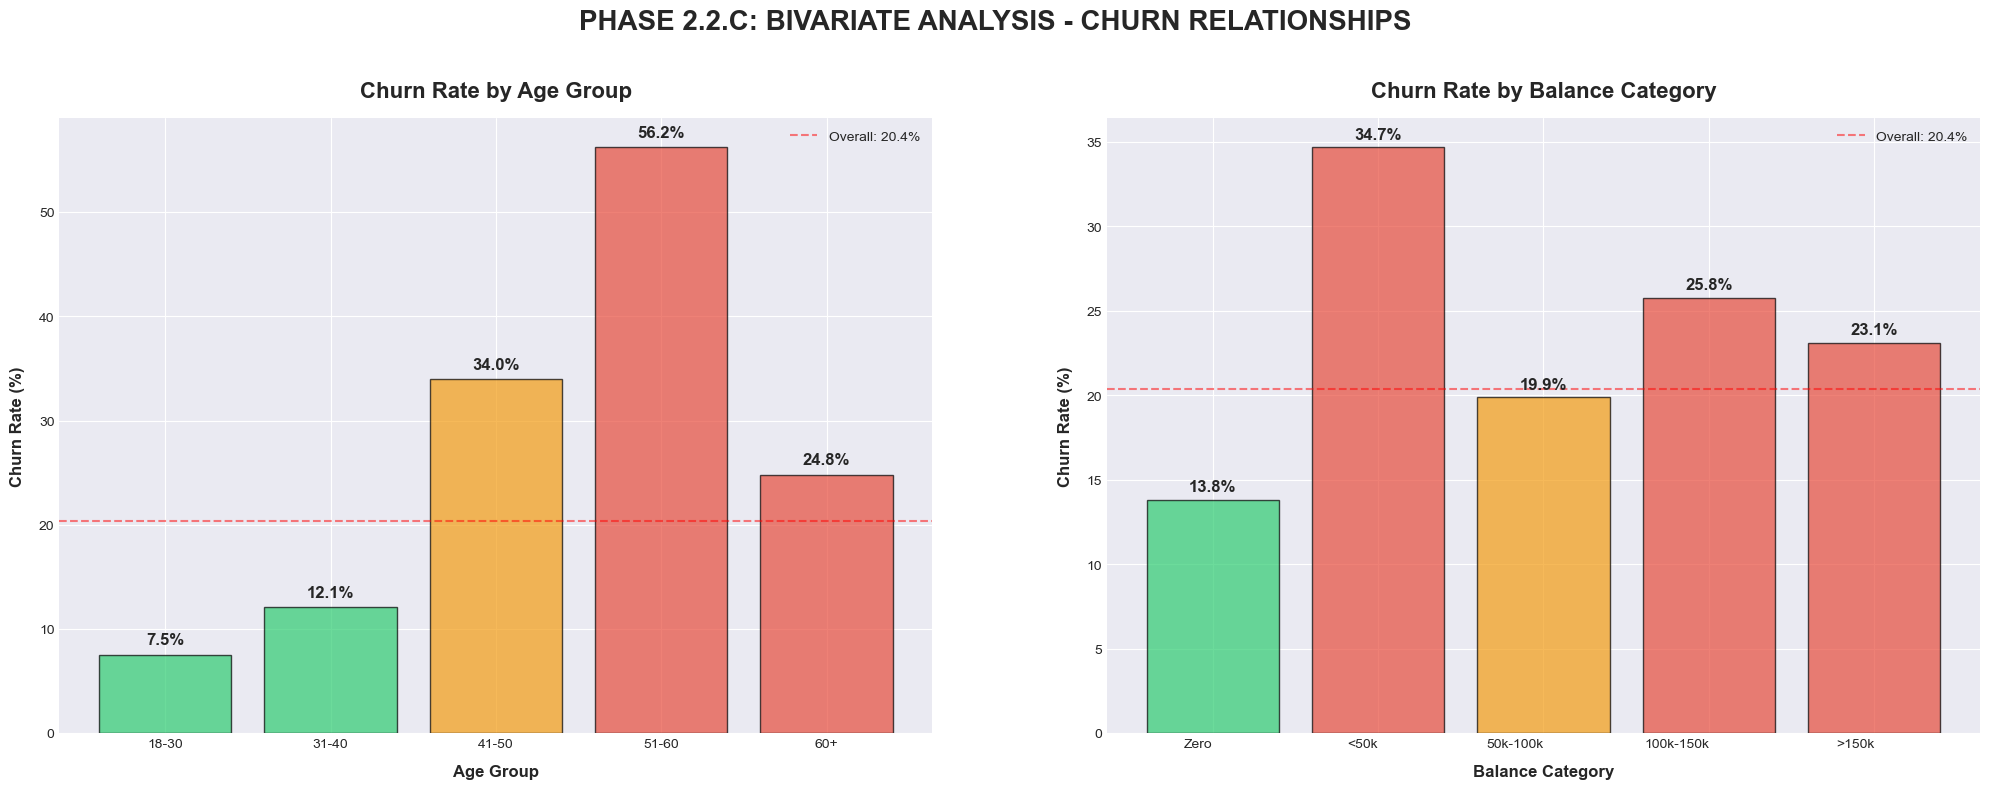

In [37]:
# Create comprehensive bivariate visualizations
fig = plt.figure(figsize=(20, 16))
fig.suptitle('PHASE 2.2.C: BIVARIATE ANALYSIS - CHURN RELATIONSHIPS', 
             fontsize=20, fontweight='bold', y=1.00)

# 9. Age Groups vs Churn Rate
ax9 = plt.subplot(2, 2, 1)
age_groups = pd.cut(df_clean['Age'], bins=[0, 30, 40, 50, 60, 100], 
                    labels=['18-30', '31-40', '41-50', '51-60', '60+'])
age_churn_rate = df_clean.groupby(age_groups)['Exited'].mean() * 100
bars = ax9.bar(age_churn_rate.index, age_churn_rate.values, 
               color=['#2ecc71', '#2ecc71', '#f39c12', '#e74c3c', '#e74c3c'], 
               edgecolor='black', alpha=0.7)
ax9.set_xlabel('Age Group', fontsize=12, fontweight='bold', labelpad=10)
ax9.set_ylabel('Churn Rate (%)', fontsize=12, fontweight='bold', labelpad=10)
ax9.set_title('Churn Rate by Age Group', fontsize=16, fontweight='bold', pad=15)
ax9.axhline(y=overall_churn_rate, color='red', linestyle='--', alpha=0.5, label=f'Overall: {overall_churn_rate:.1f}%')
ax9.legend()
for bar, val in zip(bars, age_churn_rate.values):
    ax9.text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.1f}%', 
             ha='center', fontweight='bold', fontsize=12)

# 10. Balance Categories vs Churn Rate
ax10 = plt.subplot(2, 2, 2)
balance_cats = pd.cut(df_clean['Balance'], 
                      bins=[-1, 0, 50000, 100000, 150000, 300000],
                      labels=['Zero', '<50k', '50k-100k', '100k-150k', '>150k'])
balance_churn_rate = df_clean.groupby(balance_cats)['Exited'].mean() * 100
bars = ax10.bar(balance_churn_rate.index, balance_churn_rate.values, 
                color=['#2ecc71', '#e74c3c', '#f39c12', '#e74c3c', '#e74c3c'], 
                edgecolor='black', alpha=0.7)
ax10.set_xlabel('Balance Category', fontsize=12, fontweight='bold', labelpad=10)
ax10.set_ylabel('Churn Rate (%)', fontsize=12, fontweight='bold', labelpad=10)
ax10.set_title('Churn Rate by Balance Category', fontsize=16, fontweight='bold', pad=15)
ax10.axhline(y=overall_churn_rate, color='red', linestyle='--', alpha=0.5, label=f'Overall: {overall_churn_rate:.1f}%')
ax10.legend()
ax10.set_xticklabels(ax10.get_xticklabels(), ha='right')
for bar, val in zip(bars, balance_churn_rate.values):
    ax10.text(bar.get_x() + bar.get_width()/2, val + 0.5, f'{val:.1f}%', 
             ha='center', fontweight='bold', fontsize=12)
    
fig.tight_layout(rect=[0, 0, 1, .99])   # leaves top 1% for the suptitle
fig.subplots_adjust(hspace=0.4, wspace=0.2)  # add extra vertical/horizontal padding
plt.show()

### 🎯 2.3 Target Variable Analysis
- Overall churn rate calculation
- Churn distribution visualization
- Class imbalance assessment


📊 2.3 CORRELATION ANALYSIS

📊 Correlation Matrix:
----------------------------------------
                 CreditScore   Age  Tenure  Balance  NumOfProducts  HasCrCard  IsActiveMember  EstimatedSalary  Exited
CreditScore             1.00 -0.00    0.00     0.01           0.01      -0.01            0.03            -0.00   -0.03
Age                    -0.00  1.00   -0.01     0.03          -0.03      -0.01            0.09            -0.01    0.28
Tenure                  0.00 -0.01    1.00    -0.01           0.01       0.02           -0.03             0.01   -0.01
Balance                 0.01  0.03   -0.01     1.00          -0.30      -0.01           -0.01             0.01    0.12
NumOfProducts           0.01 -0.03    0.01    -0.30           1.00       0.00            0.01             0.01   -0.05
HasCrCard              -0.01 -0.01    0.02    -0.01           0.00       1.00           -0.01            -0.01   -0.01
IsActiveMember          0.03  0.09   -0.03    -0.01           0.01      -0.

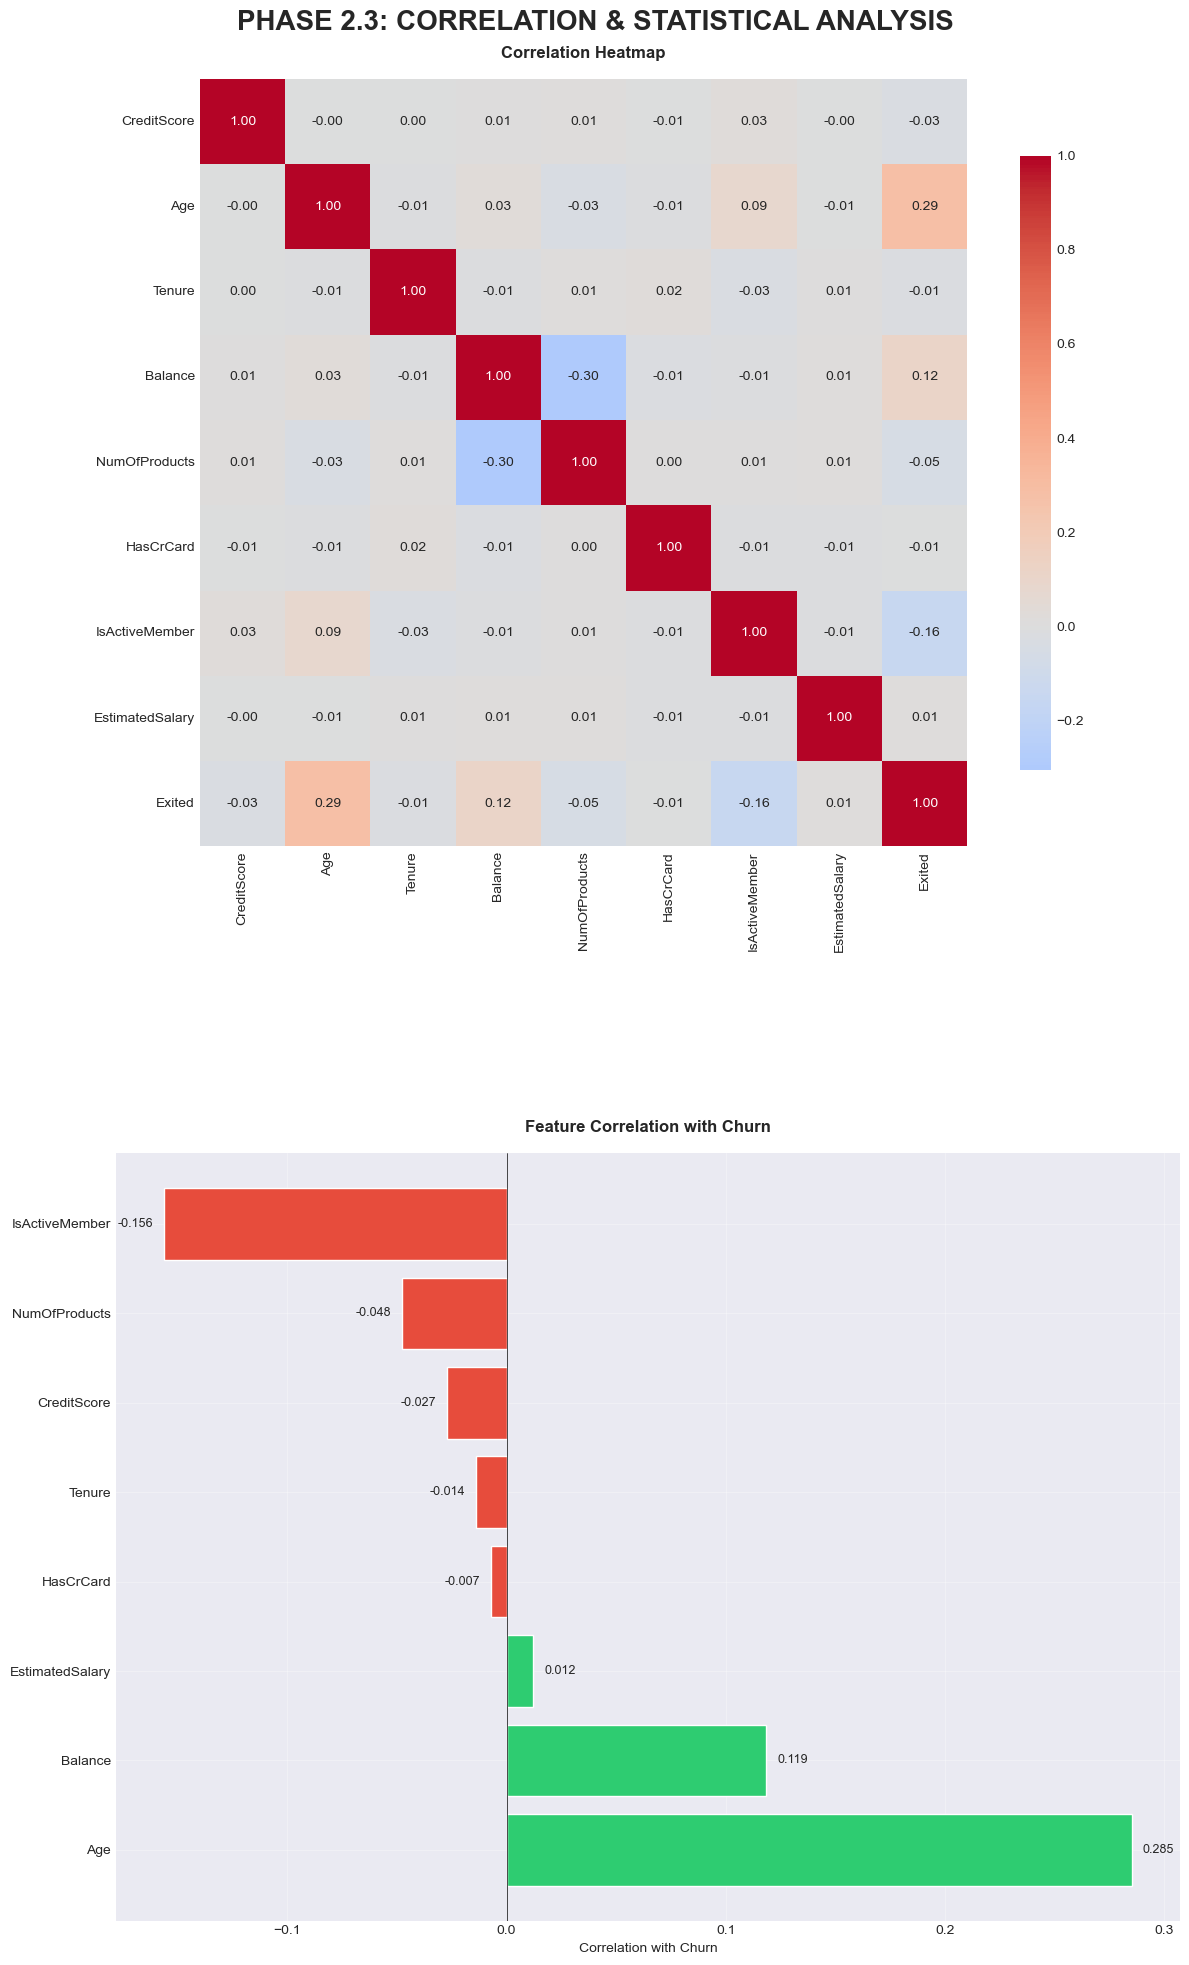

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats

print("\n" + "="*50)
print("📊 2.3 CORRELATION ANALYSIS")
print("="*50)

# Prepare data for correlation
df_corr = df_clean.copy()

# Create correlation matrix
correlation_matrix = df_corr[['CreditScore', 'Age', 'Tenure', 'Balance', 
                              'NumOfProducts', 'HasCrCard', 'IsActiveMember', 
                              'EstimatedSalary', 'Exited']].corr()

print("\n📊 Correlation Matrix:")
print("-" * 40)
print(correlation_matrix.round(3))

print("\n📌 Correlation with Churn (Exited):")
print("-" * 40)
churn_correlations = correlation_matrix['Exited'].sort_values(ascending=False)
for feature, corr in churn_correlations.items():
    if feature != 'Exited':
        strength = 'Strong' if abs(corr) > 0.3 else 'Moderate' if abs(corr) > 0.1 else 'Weak'
        direction = 'Positive' if corr > 0 else 'Negative'
        print(f"   • {feature:<20}: {corr:+.4f} ({strength} {direction})")
        
print(f"\n")

# Create figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 20))
fig.suptitle('PHASE 2.3: CORRELATION & STATISTICAL ANALYSIS', fontsize=20, fontweight='bold')

# 1. Correlation Heatmap
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, ax=ax1, cbar_kws={"shrink": 0.8})
ax1.set_title('Correlation Heatmap', fontweight='bold', pad=15)

# 2. Correlation with Churn
churn_corr = churn_correlations.drop('Exited')
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in churn_corr]
bars = ax2.barh(churn_corr.index, churn_corr.values, color=colors)
ax2.set_xlabel('Correlation with Churn')
ax2.set_title('Feature Correlation with Churn', fontweight='bold', pad=15)
ax2.axvline(0, color='black', linewidth=0.5)
ax2.grid(alpha=0.3)

# Add values
for bar, val in zip(bars, churn_corr):
    ax2.text(val + (0.005 if val > 0 else -0.005), bar.get_y() + bar.get_height()/2, 
             f'{val:.3f}', va='center', ha='left' if val > 0 else 'right', fontsize=9)

fig.tight_layout(rect=[0, 0, 1, .99])   # leaves top 1% for the suptitle
fig.subplots_adjust(hspace=0.4, wspace=0.2)  # add extra vertical/horizontal padding
plt.show()
